# Modelling and exploring Leone Allacci's _Drammaturgia_




## 0. Setup

Imports and initial data loading.

## 1. Data Extraction

In [2]:
import subprocess, sys

# Bootstrap tqdm first (needed for the progress bar below)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tqdm'], check=True)
from tqdm.notebook import tqdm

_pkgs = [
    'pandas', 'requests', 'numpy', 'matplotlib', 'seaborn',
    'folium', 'plotly', 'nltk', 'spacy', 'stanza',
    'geopy', 'scikit-learn', 'statsmodels', 'networkx', 'gender-guesser',
]

for _pkg in tqdm(_pkgs, desc='Installing packages'):
    _r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', _pkg],
        capture_output=True, text=True
    )
    if _r.returncode != 0:
        print(f'FAILED: {_pkg}\n{_r.stderr.strip()}')

import pandas as pd
import requests
import re
import csv
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.graph_objects as go
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
import stanza
from geopy.geocoders import Nominatim
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
import statsmodels.api as sm
import networkx as nx
from collections import Counter

Installing packages:   0%|          | 0/15 [00:00<?, ?it/s]

### 1.1 Extraction functions

One function per field, applied to the raw `voce/entry` text.

#### Title and subtitle

In [2]:
def extract_title(sentence):
    # Find the first element in the sentence up to the full stop
    match = re.search(r'[^.]*\.', sentence)

    if match:
        # Extract the matched text
        matched_text = match.group().strip(".")

        # Check for the presence of "ovvero" or "o sia"
        if "ovvero" in matched_text or "o sia" in matched_text:
            # Split the text into title and subtitle
            title, _, subtitle = re.split(r'\s*(ovvero|o sia|o siano)\s*', matched_text, maxsplit=1)
            title = title.strip()
            subtitle = subtitle.strip()
            if title.endswith(","):
              title = title.strip(",")
            if subtitle.startswith(", "):
              subtitle = subtitle[2:]
            return title.title(), subtitle.title()
        else:
            # If "ovvero" or "o sia" is not present, set subtitle_one to None
            title = matched_text.strip()
            return title.title(), None
    else:
        return None, None

#### Genre

In [3]:
def extract_genre(sentence):
    # Find the first full stop in the sentence
    first_full_stop_match = re.search(r'(?<!\b[SIVX])\.', sentence)

    if first_full_stop_match:
        # Find the second full stop or a parenthesis in the remaining text
        second_full_stop_match = re.search(r'\.|\(', sentence[first_full_stop_match.end():])

        if second_full_stop_match:
            # Extract text from the first full stop to the second full stop
            text_after_full_stop = sentence[first_full_stop_match.end():first_full_stop_match.end() + second_full_stop_match.start()]
            genre = text_after_full_stop.strip().strip(".|(")

            # Keep only the first two words of the genre
            genre_words = genre.split()
            genre = ' '.join(genre_words[:2])

            genre = genre.replace(" di","")
            genre = genre.replace(" per","")
            genre = re.sub(r' recitata| recitato| rappresentata| rappresentato| dedicato', '', genre)
            genre = genre.strip()

            if genre == 'Op':
                genre = 'Opera'
            if genre.startswith('Rappresentata'):
                genre = '?'
            elif genre.startswith('in') or genre.startswith('— in'):
                genre = '?'
            return genre
    else:
        return None

#### Mode

In [4]:
def extract_mode(entry):
    mode = None

    if 'prosa' in entry.lower():
        mode = 'prose'
    elif 'versi' in entry.lower() or 'ottava rima' in entry.lower():
        mode = 'verse'

    return mode

#### City

In [5]:
def extract_city(entry):

    # check for "Senza luogo" outside the loop
    if "senza luogo" in entry:
        return "?"

    # let's temporarily remove expressions which confuse the parser

    strings = ["in prosa", "in versi", "in due", "in quattro",
               "in ottava", "in terza", "in terzine", "in forma",
               "in luce", "in atto", "in cinque", "in musica",
               "in Musica", "in occasione", "in verso", "in lingua",
               "in Lingua", "in tre", "in Amore", "in data", "in una",
               "in Italiano", "in terzetti", "in Atti", "in S.",
               "in Casa", "in applauso", "in un", "in cui", "in onore",
               "recitato in", "rappresentato in"]  # we remove also what points to staging location
    for string in strings:
      if string in entry:
        entry = entry.replace(string, "")

    # remove uppercase words
    entry = re.sub(r'IN [A-Z]+', '', entry)

    city_pattern = re.compile(r'(?i)in\s([^\s\d]+)')
    match = city_pattern.search(entry)

    city = match.group(1) if match else None
    if city:
      city = city.strip(",")
      city = city.strip(".")
      if city in ["Ven", "Venez","Vinegia"]:
        city = "Venezia"
      if "." in city:
        city = city.replace(".", "")
    return city


#### Location

In [6]:
def extract_location(entry):
    # Define the pattern for capturing location after "Teatro di"
    location_pattern = re.compile(r'Teatro\s+([^\s]+)\s([^\s]+)\s([^\s]+)\s([^\s]+)\s([^\s]+)')

    # Search for the pattern in the input string
    match = location_pattern.search(entry)

    # If the pattern is found, return the matched location as a string
    if match:
        location = ' '.join(match.groups())  # Join the captured groups into a single string
        #print(location)
        location = re.sub(r"l'anno\s+\d{4}", "", location)
        location = re.sub(r"l'anno", "", location)
        location = re.sub(r"Poesia", "", location)
        if location.startswith(("de", "di")):
          location = location[3:]
        if location.endswith("di"):
          location = location[:-3]
        elif location.startswith(("Ebraico", "Comico", "Tragico", "pubblicato")):
          location = None

        return location
    else:
        return None


#### Publisher

In [7]:
def extract_publisher(entry):

    # Let's temporarily remove misdirections from the entry
    strings = ["per Musica","per comando", "di Personaggi", "per le "]
    for string in strings:
      if string in entry:
        entry = entry.replace(string, "")

    # Check for "Senza Stampatore" outside the loop
    if "senza Stampatore" in entry or "senza nome di Stampatore" in entry :
        return "?"
    if "e Stampatore" in entry or ", Stampatore" in entry :
        return "?"

    # Define sets of publisher expressions within the function
    pointer_sets = [
        ("per il ", "per gli ", "presso il ", "presso gli ", "nella Stamperia del "),
        ("per ", "pel ", "presso ", "appr\. ", "nella Stamperia ", "nella Stampa "),
        ("appresso ","ad istanza del ", "ad istanza di ", "all'Insegna ")
    ]

    # Iterate through each set of pointers
    for pub_pointers in pointer_sets:
        # Combine the current set of pointers into a regex pattern
        pub_pattern_str = '|'.join(pub_pointers)
        publisher_pattern = re.compile(fr'(?i)\b(?:{pub_pattern_str})\s*([^.,]+)[.,]')

        # Use the regex pattern to search for a match in the input string
        match = publisher_pattern.search(entry)

        # If a match is found, extract and return the publisher information
        if match:
            if "Gio." in match.group(0):
                # Take the following two words as the publisher
                publisher_words = re.findall(r'\b\w+\b', entry)
                publisher_index = publisher_words.index("Gio") + 1
                return ' '.join(publisher_words[publisher_index: publisher_index + 2])
            else:
                # Extract and return the publisher information
                publisher = match.group(1).strip()
                if publisher.startswith("l'"):
                    publisher = publisher[2:]  # Remove "l'"
                if publisher == "Pietro Van":
                  publisher = "Pietro Van Ghelen"
                if publisher == "Niccolini":
                  publisher = "Francesco Niccolini"
                if "Ducale" in publisher:
                  publisher = "Stamperia Ducale"
                if "Imperiale" in publisher:
                  publisher = "Stamperia Imperiale"
                if "della Rev" in publisher:
                  publisher = "Stamperia della Camera Apostolica"
                return publisher

    # If no match is found in any set of pointers, return None
    return None

<>:18: SyntaxWarning: invalid escape sequence '\.'
<>:18: SyntaxWarning: invalid escape sequence '\.'
C:\Users\lucag\AppData\Local\Temp\ipykernel_54680\2696484326.py:18: SyntaxWarning: invalid escape sequence '\.'
  ("per ", "pel ", "presso ", "appr\. ", "nella Stamperia ", "nella Stampa "),


#### Year

In [8]:
def extract_year(entry):

    # check for "Senza anno" outside the loop
    if "senz'anno" in entry.lower() or "senza anno" in entry.lower() or "re, ed anno" in entry.lower():
        return "Unknown"

    # Define the pattern for finding the year followed by "in"
    year_pattern = re.compile(r'(\d{4})\s*in', re.IGNORECASE)

    # Search for the pattern in the input string
    match = year_pattern.search(entry)

    # If the pattern is found, return the matched year
    if match:
        year = int(match.group(1))
        return year
    else:
        # If the pattern is not found, try finding any year pattern
        general_year_pattern = re.compile(r'(\d{4})')
        general_match = general_year_pattern.search(entry)
        general_year = int(general_match.group(1)) if general_match else None
        return general_year

#### Format

In [9]:
def extract_format(entry):
    format_pattern = re.compile(r'in\s(\d+)')
    match = format_pattern.search(entry)
    format = match.group(1) if match else None
    return format

#### Author

In [10]:
def extract_author(entry):

    # Check for "incerto" outside the loop
    if "incerto" in entry.lower():
        return "?"

    # titles and honorifics to be removed
    titles = ["Co. ","Conte ","Ab. ","Abate ", "P. ", "Padre", "Fr. ", "Monsign. ",
              "Don ", "Dott. ", "Dottore ", "Dottor ", "D. ", "Fra ", "F. ", "Marchese "]

    # Define the pattern for capturing two words after dash and "di" or "Poesia di"
    author_pattern = re.compile(r'(?:— di|— da|— del[l\']|— del|— dal|Poesia di|Poesia del)\s*([^,]+ [^,]+)')

    # Search for the pattern in the input string
    match = author_pattern.search(entry)

    # If the pattern is found, return the matched author
    if match:
        author = match.group(1).strip()
        # remove titles
        for title in titles:
          if title in author:
            author = author.replace(title, "")
        # fix residual issues
        author = re.sub(r'\. — .*$', '', author)
        author = author.strip(".,")
        if author.startswith("l'"):
            author = author.replace("l'", "")
        if author.startswith("l "):
            author = author[2:]
        if author.startswith("'"):
            author = author.replace("'", "")
        if author.endswith("."):
          author = author.replace(".", "")
        if author.startswith("Polisseno Fegejo Pastor Arcade"):
                author = "Carlo Goldoni"
        return author
    else:
        return None

#### Libretto

In [11]:
def check_if_libretto(entry):
    libretto = None

    if 'musica di' in entry.lower() or 'per musica' in entry.lower():
        libretto = True
    else:
        libretto = False

    return libretto

#### Composer

In [12]:
def extract_composer(entry):

    # Check for "incerto" outside the loop
    if "musica d'incerto" in entry.lower():
        return "?"
    if "musica di diversi" in entry.lower():
        return "?"

    # titles and honorifics to be removed
    titles = ["Co. ","Conte ","Ab. ","Abate ", "P. ", "Padre", "Fr. ", "Monsign. ",
              "Don ", "Dott. ", "Dottore ", "Dottor ", "D. ", "Fra ", "F. ", "Marchese "]

    # Define the pattern for capturing composer
    composer_pattern = re.compile(r'(?:Musica di|Musica del)\s*([^,]+ [^,]+)')

    # Search for the pattern in the input string
    match = composer_pattern.search(entry)

    # If the pattern is found, return the matched composer
    if match:
        try:
          composer = match.group(1).strip()
          # remove titles
          for title in titles:
            if title in composer:
              composer = composer.replace(title, "")
          # fix residual issues
          composer = re.sub(r'\. — .*$', '', composer)
          composer = re.sub(r'Cav\.', '', composer)
          composer = composer.strip(".,")
          if composer.startswith("l'"):
              composer = composer.replace("l'", "")
          if composer.startswith(" "):
              composer = composer.replace(" ", "")
          if composer.startswith("l "):
              composer = composer[2:]
          if composer.startswith("'"):
              composer = composer.replace("'", "")
          if composer.endswith("."):
            composer = composer.replace(".", "")
          return composer
        except:
          return None
    else:
        return None

#### Translation

In [13]:
def check_if_translation(entry):
    translation = None

    if 'tradot' in entry.lower() or "traduz" in entry.lower():
        translation = True
    else:
        translation = False

    return translation

### 1.2 Apply functions & build DataFrame

In [14]:
url = 'https://raw.githubusercontent.com/allacci-digitale/allacci-digitale.github.io/main/data/cleaned-transcription.txt'
response = requests.get(url).text
entries = response.split('\n')

# Create a DataFrame
df = pd.DataFrame({"voce/entry": entries})

In [15]:
# extract info and fill the df

df['titolo/title'], df['sottitolo/subtitle'] = zip(*df['voce/entry'].apply(extract_title))
df['autore/author'] = df['voce/entry'].apply(extract_author)
df['genere/genre'] = df['voce/entry'].apply(extract_genre)
df['metro/mode'] = df['voce/entry'].apply(extract_mode)
df['luogo di pubblicazione/city'] = df['voce/entry'].apply(extract_city)
df['luogo di rappresentazione/location'] = df['voce/entry'].apply(extract_location)
df['editore/publisher'] = df['voce/entry'].apply(extract_publisher)

df['anno/year'] = df['voce/entry'].apply(extract_year)
df['anno/year'] = pd.to_numeric(df['anno/year'], errors='coerce')
df['anno/year'] = df['anno/year'].fillna(0).astype(int)

df['formato/format'] = df['voce/entry'].apply(extract_format)
df['libretto'] = df['voce/entry'].apply(check_if_libretto)
df['compositore/composer'] = df['voce/entry'].apply(extract_composer)
df['traduzione/translation'] = df['voce/entry'].apply(check_if_translation)

# Display the resulting DataFrame
df.head(5)

,voce/entry,titolo/title,sottitolo/subtitle,autore/author,genere/genre,metro/mode,luogo di pubblicazione/city,luogo di rappresentazione/location,editore/publisher,anno/year,formato/format,libretto,compositore/composer,traduzione/translation
0,ABBAGLI FELICI. Commedia (in prosa). — In Mace...,Abbagli Felici,NaN,Prospero Bonarelli della Rovere,Commedia,prose,Macerata,NaN,Agostino Grisei,1642,12,False,NaN,False
1,ABBANDONO D'ARMIDA. Trattenimento scenico cant...,Abbandono D'Armida,NaN,Giovanni Boldini,Trattenimento scenico,verse,Venezia,Grimani di San Gian—Grisostomo,Carlo Buonarrigo,1729,12,True,?,False
2,ABBATE. Commedia (in prosa). — in Venez. appre...,Abbate,NaN,Bartolommeo Cappello,Commedia,prose,Venezia,NaN,Agostino Bindoni,1556,8,False,NaN,False
3,ABBISAI. Op. (in prosa). — in Milano per il Ma...,Abbisai,NaN,Carlo Giuseppe Cornacchia,Opera,prose,Milano,NaN,Malatesta,1718,12,False,NaN,False
4,ABDOLOMINO. Dramma rappresentato alle Sac. Ces...,Abdolomino,NaN,Silvio Stampiglia,Dramma,NaN,Vienna,NaN,gli Eredi Cosmeroviani,1709,8,True,Giovanni Bononcini,False


### 1.3 Validation

In [16]:
# debug nones

none_entries = df.loc[df['autore/author'].isnull(), "voce/entry"]

for entry in none_entries:
    print(entry)

ACARNE. Commedia di Aristofane tradotta dal Greco in Lingua comun d'Italia. — in Vinegia, appr. Vincenzo Valgrisi. 1545 in 8 — di Bartolommeo, e Pietro Fratelli Rositini, da Pratalboino.
ACCIDENTI D'AMORE. Commedia (in prosa). in Ven. appresso Angiol Salvadori. 1635. in 12. dal Dot. Fulvio Genga di Fano.
ADAMIRA, ovvero, la Statua dell'Onore. Opera Scenica (in prosa). — in Ven. appr. Giacomo Batti. / 1657. in 12. — in Perugia, per Sebastian Zecchini, 1659. in 12. — in Venez. per il Pezzana 1662 in 12. — ed in Bologna, per Giacomo Monti. Senz'anno. in 12. E la stessa che l'Amore nella Statua, di Giacinto Andrea Cicognini, Fiorentino.
ADARCONTE. Tragedia (in prosa). — in Roma, per Michiel Ercole. 1676.
ADONE. Pastorale Drammatica. — in Napoli, per Tarquinio Longo. 1614. in 4. con le altre Poesie dell'Autore— Poesia di Marcello—Macedonio.
ADRIANO. Tragedia di Giuseppe Squillaci, di Catania.
ALBIDO. Favola Pastorale. — in Roma, per Giacomo Mascardi, 1624 in 12. — ed ivi, per Lodovico Grigh

In [17]:
# debug strange stuff
unique_values = df['luogo di rappresentazione/location'].value_counts()
sorted_values = unique_values.sort_values(ascending=False)
for value, frequency in sorted_values.items():
  #if type(value) == int and value < 1500:
  print(f"{value} {frequency}")

Sant'Angiolo di Venezia  123
S. Gio. Grisostomo 64
 SS. Gio. e Paolo 49
S. Cassiano di Venezia 41
S. Mosè di Venezia 34
S. Salvatore di Venezia 34
San Cassiano di Venezia 32
San Mosè di Venezia 23
San Salvatore di Venezia 19
SS. Gio. e Paolo 17
S. Fantino di Venezia 12
San Fantino di Venezia 12
Sant'Apollinare di Venezia  12
San Gio. Grisostomo 12
San Samuele di Venezia 10
San Mosè  10
S. Cassiano  9
Formagliari di Bologna. —  8
Formagliari di Bologna  7
S. Samuele di Venezia 7
 S. S. Gio. e 6
S. Cassiano di Venezia. 6
S. Mosè  6
S. Salvatore. — in 5
S. Mose di Venezia 5
S. S. Gio. e 5
San Cassiano  5
S. Mosè. — in 4
S. Gio. Grisostomo. — 4
Obizzi di Padova  4
Marsigli Rossi di Bologna. — 4
S. Angiolo di Venezia 4
Sant'Angiolo di Venezia. — 4
San Gio. Grisostomo  4
S. Gio. Grisostomo  4
Sant'Angiolo  in 4
 SS. Gio. e Paolo. 3
S. Angelo di Venezia 3
 Sig. Co. Pinamonte Bonacossi. 3
Ducale di Piacenza  3
San Cassiano di Venezia. 3
Sant'Angiolo di Venezia anno 3
 Falcone di Genova  3
Mila

In [18]:
# find recurrent empty fields

for column in df.columns:
    none_count = df[column].apply(lambda x: x is None).sum()
    total_entries = len(df[column])
    percent_none = ((none_count / total_entries) * 100 if total_entries > 0 else 0).round(2)
    print(f"In the '{column}' column there are {none_count} None values out of {total_entries} ---> {percent_none}")

In the 'voce/entry' column there are 0 None values out of 6076 ---> 0.0
In the 'titolo/title' column there are 0 None values out of 6076 ---> 0.0
In the 'sottitolo/subtitle' column there are 0 None values out of 6076 ---> 0.0
In the 'autore/author' column there are 0 None values out of 6076 ---> 0.0
In the 'genere/genre' column there are 0 None values out of 6076 ---> 0.0
In the 'metro/mode' column there are 0 None values out of 6076 ---> 0.0
In the 'luogo di pubblicazione/city' column there are 0 None values out of 6076 ---> 0.0
In the 'luogo di rappresentazione/location' column there are 0 None values out of 6076 ---> 0.0
In the 'editore/publisher' column there are 0 None values out of 6076 ---> 0.0
In the 'anno/year' column there are 0 None values out of 6076 ---> 0.0
In the 'formato/format' column there are 0 None values out of 6076 ---> 0.0
In the 'libretto' column there are 0 None values out of 6076 ---> 0.0
In the 'compositore/composer' column there are 0 None values out of 6076

### 1.4 Export

In [19]:
df.to_csv("database.csv")
#df.to_json("database.json") # this fails

csv_file = 'database.csv'
json_file = 'database.json'

with open(csv_file, 'r') as f:
    csv_data = [dict(row) for row in csv.DictReader(f)]

with open(json_file, 'w') as f:
    json.dump(csv_data, f, indent=4)


## 2. Exploratory Data Analysis

In [3]:
from pathlib import Path
import pandas as pd

_db_cache = Path('data/database_cache.json')
_db_url   = 'https://raw.githubusercontent.com/allacci-digitale/allacci-digitale.github.io/main/data/database.json'

if _db_cache.exists():
    df = pd.read_json(_db_cache)
    print(f'Loaded df from local cache ({len(df)} rows).')
else:
    df = pd.read_json(_db_url)
    _db_cache.parent.mkdir(parents=True, exist_ok=True)
    df.to_json(_db_cache, orient='records', force_ascii=False)
    print(f'Fetched df from GitHub and cached locally ({len(df)} rows).')

df.head(1)


Loaded df from local cache (6076 rows).


,voce/entry,titolo/title,sottotitolo/subtitle,autore/author,genere/genre,metro/mode,luogo di pubblicazione/city,luogo di rappresentazione/location,editore/publisher,anno/year,formato/format,libretto,compositore/composer,traduzione/translation
0,ABBAGLI FELICI. Commedia (in prosa). — In Mace...,Abbagli Felici,,"<a href=""https://www.wikidata.org/wiki/Q340782...",commedia,prose,"<a href=""https://www.wikidata.org/wiki/Q13135""...",,"<a href=""https://www.wikidata.org/wiki/Q118733...",1642,12,False,,False


In [21]:
top_publishers = df['editore/publisher'].value_counts().head(12).index

for publisher in top_publishers:
    publisher_df = df[df['editore/publisher'] == publisher]
    top_genres = publisher_df['genere/genre'].value_counts().head(3)
    print(f"Publisher: {publisher}")
    print(top_genres)
    print("---")

Publisher: unknown
genere/genre
dramma              228
commedia            143
rappresentazione     71
Name: count, dtype: int64
---
Publisher: <a href="https://www.wikidata.org/wiki/Q122599209">Marino Rossetti</a>
genere/genre
dramma        179
tragedia       12
intermezzi      8
Name: count, dtype: int64
---
Publisher: Francesco Niccolini
genere/genre
dramma             194
melodramma           3
dramma musicale      3
Name: count, dtype: int64
---
Publisher: <a href="https://www.wikidata.org/wiki/Q98645100">Giuseppe Longhi</a>
genere/genre
opera       32
tragedia    30
commedia    28
Name: count, dtype: int64
---
Publisher: <a href="https://www.wikidata.org/wiki/Q1695821">Johann Peter van Ghelen</a>
genere/genre
dramma                 29
azione sacra           26
poemetto drammatico     7
Name: count, dtype: int64
---
Publisher: <a href="https://www.wikidata.org/wiki/Q6520898">Lelio Dalla Volpe</a>
genere/genre
tragedia    55
commedia     6
             4
Name: count, dtype: int64


#### Locations

In [22]:
ranked_locations_1 = df['luogo di pubblicazione/city'].value_counts()
print(ranked_locations_1)

luogo di pubblicazione/city
<a href="https://www.wikidata.org/wiki/Q641">Venice</a>               1927
<a href="https://www.wikidata.org/wiki/Q1891">Bologna</a>              518
<a href="https://www.wikidata.org/wiki/Q2044">Florence</a>             394
<a href="https://www.wikidata.org/wiki/Q220">Rome</a>                  369
<a href="https://www.wikidata.org/wiki/Q2634">Naples</a>               367
                                                                      ... 
<a href="https://www.wikidata.org/wiki/Q111289">Scandiano</a>            1
<a href="https://www.wikidata.org/wiki/Q42793">Crema</a>                 1
<a href="https://www.wikidata.org/wiki/Q7024">Lugano</a>                 1
<a href="https://www.wikidata.org/wiki/Q111155035">Libertapoli</a>       1
<a href="https://www.wikidata.org/wiki/Q239">City of Brussels</a>        1
Name: count, Length: 135, dtype: int64


In [23]:
# prompt: from all items in ranked location[luogo di pubblicazione/city], keep only the string after > and before <. new df should have only the columns city-name and counts (counting how many times in original df)


# Assuming df is already loaded as in the provided code.
# Example df (replace with your actual df)
# ... (your code to load df) ...


def extract_city_name(location_string):
    match = re.search(r">([^<]+)<", location_string)
    if match:
        return match.group(1)
    else:
        return None


# Apply the function to the 'luogo di pubblicazione/city' column
df['city-name'] = df['luogo di pubblicazione/city'].apply(extract_city_name)

# Group by 'city-name' and count occurrences
city_counts = df.groupby('city-name')['city-name'].count().reset_index(name='counts')


# Display the new DataFrame
city_counts

,city-name,counts
0,Ancona,24
1,Anspach,1
2,Arezzo,16
3,Ascoli Piceno,3
4,Assisi,1
...,...,...
122,Vienna,249
123,Vilnius,1
124,Viterbo,96
125,Warsaw,1


## 3. Geographic Analysis

### 3.1 Extract and geocode city names

In [24]:
import time, numpy as np
from pathlib import Path

CITY_CSV = Path('data/city_counts.csv')

geolocator = Nominatim(user_agent='allacci_geocoder', timeout=10)

def get_coords(city, retries=3):
    for attempt in range(retries):
        try:
            time.sleep(1.1)  # Nominatim policy: max 1 req/s
            location = geolocator.geocode(city)
            if location:
                return float(location.latitude), float(location.longitude)
            return np.nan, np.nan
        except Exception as e:
            wait = 5 * (attempt + 1)
            print(f'  [{city}] attempt {attempt+1} failed: {e}. Retrying in {wait}s...')
            time.sleep(wait)
    print(f'  [{city}] giving up after {retries} attempts.')
    return np.nan, np.nan

if CITY_CSV.exists():
    city_counts = pd.read_csv(CITY_CSV)
    city_counts = city_counts[city_counts['city-name'].notna()].reset_index(drop=True)
    city_counts['Latitude']  = pd.to_numeric(city_counts['Latitude'],  errors='coerce')
    city_counts['Longitude'] = pd.to_numeric(city_counts['Longitude'], errors='coerce')
    pending = city_counts[city_counts['Latitude'].isna()]
    if pending.empty:
        print(f'Loaded {len(city_counts)} cities from cache. All geocoded.')
    else:
        print(f'Resuming: {len(pending)} cities to geocode out of {len(city_counts)}...')
        for idx_row, row in pending.iterrows():
            city = row['city-name']
            lat, lon = get_coords(city)
            city_counts.loc[idx_row, 'Latitude']  = lat
            city_counts.loc[idx_row, 'Longitude'] = lon
            city_counts.to_csv(CITY_CSV, index=False)
            done = city_counts['Latitude'].notna().sum()
            status = f'{lat:.4f}, {lon:.4f}' if pd.notna(lat) else 'failed'
            print(f'  [{done}/{len(city_counts)}] {city}: {status}')
        print('Geocoding complete.')
else:
    CITY_CSV.parent.mkdir(parents=True, exist_ok=True)
    city_counts = city_counts[city_counts['city-name'].notna()].reset_index(drop=True)
    city_counts['Latitude']  = np.nan
    city_counts['Longitude'] = np.nan
    city_counts.to_csv(CITY_CSV, index=False)
    print(f'Starting geocoding for {len(city_counts)} cities...')
    for idx_row, row in city_counts.iterrows():
        city = row['city-name']
        lat, lon = get_coords(city)
        city_counts.loc[idx_row, 'Latitude']  = lat
        city_counts.loc[idx_row, 'Longitude'] = lon
        city_counts.to_csv(CITY_CSV, index=False)
        done = city_counts['Latitude'].notna().sum()
        status = f'{lat:.4f}, {lon:.4f}' if pd.notna(lat) else 'failed'
        print(f'  [{done}/{len(city_counts)}] {city}: {status}')
    print('Geocoding complete.')

print(city_counts[['city-name','Latitude','Longitude']])


Resuming: 1 cities to geocode out of 126...
  [125/126] Libertapoli: failed
Geocoding complete.
         city-name   Latitude  Longitude
0           Ancona  43.480119  13.218728
1          Anspach  50.291679   8.506878
2           Arezzo  43.517144  11.763928
3    Ascoli Piceno  42.883420  13.539593
4           Assisi  43.071195  12.614667
..             ...        ...        ...
121        Vicenza  45.634859  11.406354
122         Vienna  48.208354  16.372504
123        Vilnius  54.687046  25.282911
124        Viterbo  42.492952  11.948814
125         Warsaw  52.233374  21.071149

[126 rows x 3 columns]


In [25]:
city_counts

,city-name,counts,Latitude,Longitude,Reverse_Check
0,Ancona,24,43.480119,13.218728,NaN
1,Anspach,1,50.291679,8.506878,NaN
2,Arezzo,16,43.517144,11.763928,NaN
3,Ascoli Piceno,3,42.883420,13.539593,NaN
4,Assisi,1,43.071195,12.614667,NaN
...,...,...,...,...,...
121,Vicenza,56,45.634859,11.406354,NaN
122,Vienna,249,48.208354,16.372504,NaN
123,Vilnius,1,54.687046,25.282911,NaN
124,Viterbo,96,42.492952,11.948814,NaN


In [26]:
geo_df = pd.read_csv('data/city_counts.csv')
# Drop rows with no resolvable city name or ungeocodable placeholders
geo_df = geo_df[geo_df['city-name'].notna()].reset_index(drop=True)
geo_df = geo_df[geo_df['city-name'] != 'Libertapoli'].reset_index(drop=True)
geo_df.loc[geo_df['city-name'] == 'Bari', ['Latitude', 'Longitude']] = 41.1171, 16.8714
geo_df.loc[geo_df['city-name'] == 'City of Brussels', ['Latitude', 'Longitude']] = 50.851625815466264, 4.353097167915996
geo_df.loc[geo_df['city-name'] == 'Ceneda', ['Latitude', 'Longitude']] = 45.983010385431406, 12.305818688888884
geo_df.loc[geo_df['city-name'] == 'Cologne', ['Latitude', 'Longitude']] = 50.94051824907486, 6.958971111642418
geo_df.loc[geo_df['city-name'] == 'Lintz', ['Latitude', 'Longitude']] = 48.302564832608894, 14.297928305330455
geo_df.loc[geo_df['city-name'] == 'Monaco', ['Latitude', 'Longitude']] = 48.133258896911144, 11.578213631299127
geo_df.loc[geo_df['city-name'] == 'Livorno', ['Latitude', 'Longitude']] = 43.551139974080684, 10.307404569567463
geo_df.loc[geo_df['city-name'] == 'Monteleone', ['Latitude', 'Longitude']] = 43.04825761537117, 13.529926023355634
geo_df


,city-name,counts,Latitude,Longitude,Reverse_Check
0,Ancona,24,43.480119,13.218728,NaN
1,Anspach,1,50.291679,8.506878,NaN
2,Arezzo,16,43.517144,11.763928,NaN
3,Ascoli Piceno,3,42.883420,13.539593,NaN
4,Assisi,1,43.071195,12.614667,NaN
...,...,...,...,...,...
120,Vicenza,56,45.634859,11.406354,NaN
121,Vienna,249,48.208354,16.372504,NaN
122,Vilnius,1,54.687046,25.282911,NaN
123,Viterbo,96,42.492952,11.948814,NaN


### 3.2 Map visualisation

In [27]:
# Create a folium map centered at the mean latitude and longitude
m = folium.Map(location=[geo_df['Latitude'].mean(), geo_df['Longitude'].mean()], zoom_start=6)

# Iterate through the DataFrame and add CircleMarkers
for _, row in geo_df.iterrows():
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),
        radius=row['counts'] / 80,  # Adjust the divisor to control the circle size
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.4,
        popup=row['city-name'] + ":" + str(row['counts'])
    ).add_to(m)

# Display the map
m
# m.save('city_map.html')  # Save the map as an HTML file

### 2.1 Genre distribution

In [28]:
df.columns

Index(['voce/entry', 'titolo/title', 'sottotitolo/subtitle', 'autore/author',
       'genere/genre', 'metro/mode', 'luogo di pubblicazione/city',
       'luogo di rappresentazione/location', 'editore/publisher', 'anno/year',
       'formato/format', 'libretto', 'compositore/composer',
       'traduzione/translation', 'city-name'],
      dtype='str')

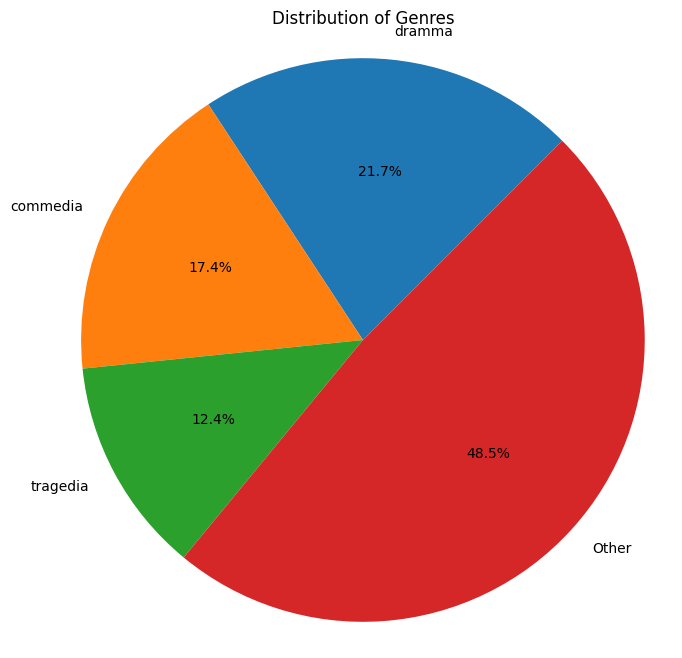

In [29]:
# prompt: piechart from the column df[genere/genre], everything under 5% goes into an "other" slice


# Assuming 'df' is your DataFrame and 'genere/genre' is the column name.
# Replace 'genere/genre' with the actual column name if it's different.

def plot_genre_piechart(df, column_name='genere/genre'):
    genre_counts = df[column_name].value_counts()
    total_count = genre_counts.sum()

    # Calculate percentages and identify genres below the 5% threshold
    percentages = genre_counts / total_count * 100
    other_genres = percentages[percentages < 5].index
    other_count = genre_counts[other_genres].sum()

    # Create the pie chart data with the 'Other' category
    pie_chart_data = percentages[percentages >= 5]
    if other_count > 0:
        pie_chart_data['Other'] = other_count / total_count * 100

    # Create the pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(pie_chart_data, labels=pie_chart_data.index, autopct='%1.1f%%', startangle=45)
    plt.title('Distribution of Genres')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()


plot_genre_piechart(df)

In [30]:
# prompt: print top most frequent items from the column "editore/publisher" of df, and next to them, the count of all the autori/authors in the same row, don't count the same author twice


# Assuming 'df' is your DataFrame loaded from the JSON file as shown in your code.
# If not, load your DataFrame here first.

def top_frequent_publishers_with_author_counts(df, top_n=10):
    """
    Prints the top N most frequent publishers and the count of unique authors associated with them.
    """
    publisher_counts = df.groupby("editore/publisher")["autore/author"].nunique().sort_values(ascending=False)

    for publisher, author_count in publisher_counts.head(top_n).items():
        print(f"{publisher}: {author_count}")

# Example usage:
top_frequent_publishers_with_author_counts(df, top_n=10) # prints the top 10 publishers and unique authors


unknown: 373
<a href="https://www.wikidata.org/wiki/Q98645100">Giuseppe Longhi</a>: 89
<a href="https://www.wikidata.org/wiki/Q122599209">Marino Rossetti</a>: 73
Francesco Niccolini: 61
<a href=\"https://www.wikidata.org/wiki/Q24238356\">unknown</a>: 36
<a href="https://www.wikidata.org/wiki/Q93123102">Giacomo Monti</a>: 28
<a href="https://www.wikidata.org/wiki/Q3107961">Giunti</a>: 26
<a href="https://www.wikidata.org/wiki/Q19569565">Domenico Lovisa</a>: 26
Carlo Buonarrigo: 26
<a href="https://www.wikidata.org/wiki/Q17279972">Giovanni Battista Ciotti</a>: 24


In [31]:
count_entries = ((df['anno/year'] >= 1561) & (df['anno/year'] <= 1710)).sum()
print("Number of texts between 1561 and 1710:", count_entries)

Number of texts between 1561 and 1710: 3818


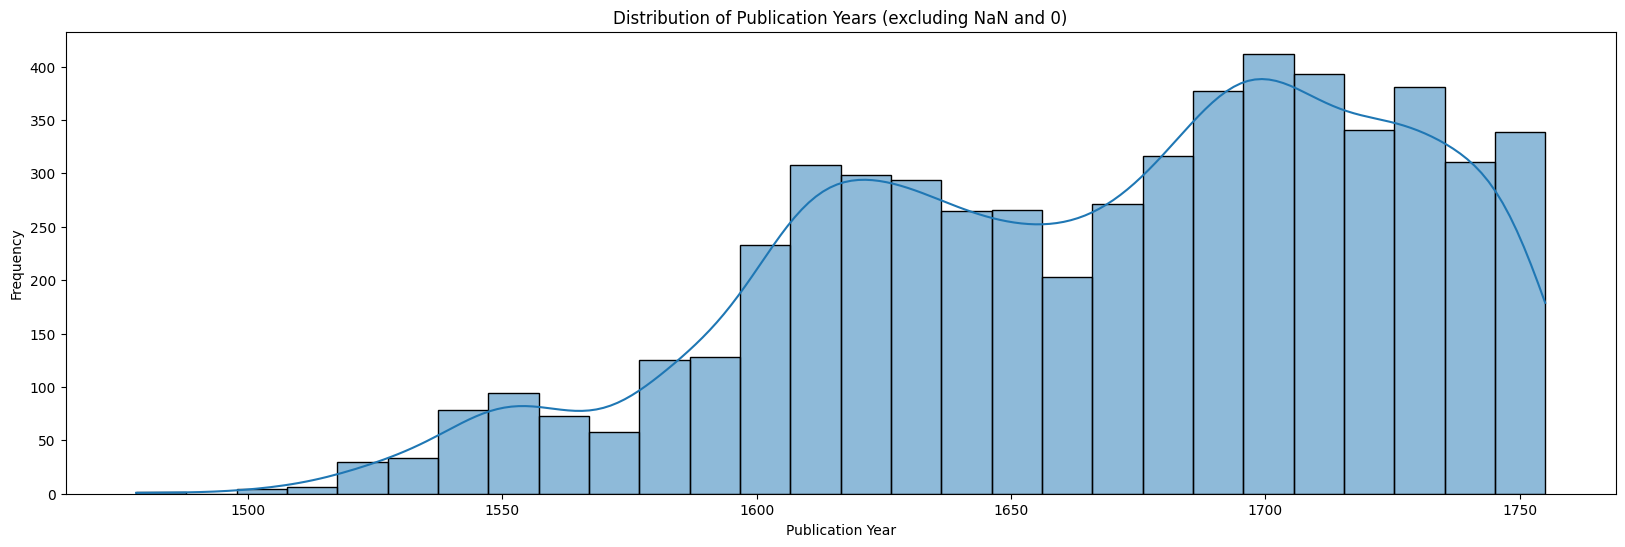

In [32]:
# prompt: histogram based on df["anno/year"]. ignore all items where anno/year is nan or 0


# Assuming your dataframe is named 'df' and has already been loaded.
# If not, load it here using pd.read_csv('your_file.csv') or pd.read_json('your_file.json').


# Filter out NaN and 0 values in 'anno/year' column
filtered_df = df[(df['anno/year'].notna()) & (df['anno/year'] != 0)]

# Create the histogram
plt.figure(figsize=(20, 6))  # Adjust figure size as needed
sns.histplot(filtered_df['anno/year'], kde=True) # Use seaborn's histplot with KDE for smoother distribution visualization
plt.title('Distribution of Publication Years (excluding NaN and 0)')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')
plt.show()

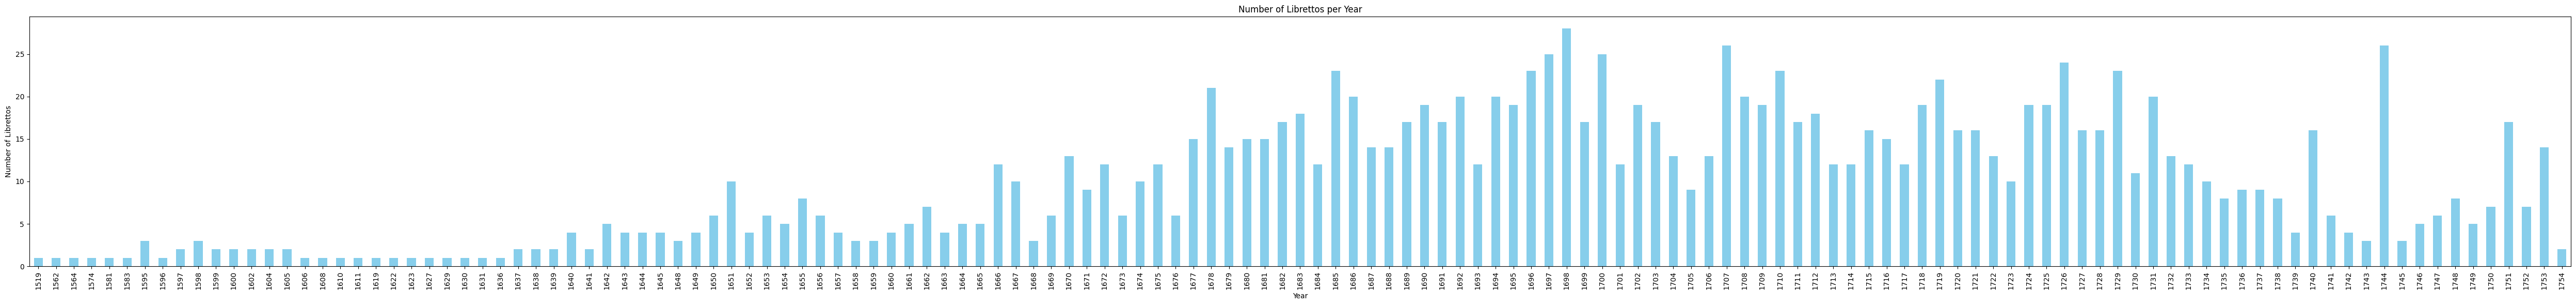

In [33]:
# Filter out invalid years, format in boolean, filter out non-libretti
filtered_df = df[(df['anno/year'].notna()) & (df['anno/year'] != 0)]
filtered_df['libretto'] = filtered_df['libretto'].apply(lambda x: str(x).lower() == 'true')
libretto_df = filtered_df[filtered_df['libretto']]

# Check if the resulting DataFrame is empty
if libretto_df.empty:
    print("No data available after filtering. Please check the 'anno/year' and 'libretto' columns.")
else:
    # Group by year and count the number of librettos
    libretto_counts = libretto_df.groupby('anno/year')['libretto'].count()

    # Plot the histogram
    plt.figure(figsize=(50, 6))
    libretto_counts.plot(kind='bar', color='skyblue')
    plt.title('Number of Librettos per Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Librettos')
    plt.tight_layout()
    plt.show()


In [34]:
top_locations = df['luogo di pubblicazione/city'].value_counts()
top_locations

luogo di pubblicazione/city
<a href="https://www.wikidata.org/wiki/Q641">Venice</a>               1927
<a href="https://www.wikidata.org/wiki/Q1891">Bologna</a>              518
<a href="https://www.wikidata.org/wiki/Q2044">Florence</a>             394
<a href="https://www.wikidata.org/wiki/Q220">Rome</a>                  369
<a href="https://www.wikidata.org/wiki/Q2634">Naples</a>               367
                                                                      ... 
<a href="https://www.wikidata.org/wiki/Q111289">Scandiano</a>            1
<a href="https://www.wikidata.org/wiki/Q42793">Crema</a>                 1
<a href="https://www.wikidata.org/wiki/Q7024">Lugano</a>                 1
<a href="https://www.wikidata.org/wiki/Q111155035">Libertapoli</a>       1
<a href="https://www.wikidata.org/wiki/Q239">City of Brussels</a>        1
Name: count, Length: 135, dtype: int64

In [35]:
import time


# Extract counts with only the Wikidata IDs
url_counts = df['luogo di pubblicazione/city'].value_counts().to_dict()

# Regular expression to extract the Wikidata ID (e.g., Q40996)
id_counts = {}
for html, count in url_counts.items():
    match = re.search(r'/wiki/(Q\d+)', html)  # Finds 'Q' followed by digits
    if match:
        wikidata_id = match.group(1)
        id_counts[wikidata_id] = count

# Proceed with the cleaned `id_counts` dictionary
unique_ids = list(id_counts.keys())

# Function to fetch coordinates for a batch of Wikidata IDs
def fetch_coordinates(batch):
    # Construct SPARQL query for the batch
    sparql_query = """
    SELECT ?place ?lat ?lon WHERE {
      VALUES ?place {""" + " ".join(f"wd:{qid}" for qid in batch) + """}
      ?place wdt:P625 ?coord.
      ?coord wikibase:latitude ?lat;
             wikibase:longitude ?lon.
    }
    """

    # Send the request to the Wikidata SPARQL endpoint
    sparql_url = "https://query.wikidata.org/sparql"
    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "AllacciDigitale/1.0 (https://allacci-digitale.github.io) python-requests"
    }
    try:
        response = requests.get(sparql_url, params={'query': sparql_query}, headers=headers, timeout=10)
        response.raise_for_status()  # Raises an error for 4xx or 5xx HTTP codes
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Request error: {e}")
        return None

# Fetch data in batches and compile results
coordinates = {}
batch_size = 50  # Define the batch size
for i in range(0, len(unique_ids), batch_size):
    batch = unique_ids[i:i + batch_size]
    data = fetch_coordinates(batch)
    if data:
        for item in data['results']['bindings']:
            qid = item['place']['value'].split('/')[-1]
            lat = float(item['lat']['value'])
            lon = float(item['lon']['value'])
            count = id_counts.get(qid, 1)
            coordinates[qid] = ((lat, lon), count)
    time.sleep(1)  # Pause to avoid rate limiting

# Plot results on a map
m = folium.Map(location=[0, 0], zoom_start=2)

# Add markers with size based on count
for qid, ((lat, lon), count) in coordinates.items():
    folium.CircleMarker(
        location=[lat, lon],
        radius=5 + count * 0.5,
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{qid} (count: {count})"
    ).add_to(m)

# Save and display map
m.save("map_with_counts.html")
m  # For Jupyter notebooks


Request error: 403 Client Error: Forbidden for url: https://query.wikidata.org/sparql?query=%0A++++SELECT+%3Fplace+%3Flat+%3Flon+WHERE+%7B%0A++++++VALUES+%3Fplace+%7Bwd%3AQ641+wd%3AQ1891+wd%3AQ2044+wd%3AQ220+wd%3AQ2634+wd%3AQ1741+wd%3AQ2656+wd%3AQ2751+wd%3AQ490+wd%3AQ13395+wd%3AQ13362+wd%3AQ617+wd%3AQ2028+wd%3AQ6247+wd%3AQ6537+wd%3AQ279+wd%3AQ13135+wd%3AQ2683+wd%3AQ1449+wd%3AQ30029567+wd%3AQ3437+wd%3AQ929804+wd%3AQ13373+wd%3AQ495+wd%3AQ6221+wd%3AQ2079+wd%3AQ13666+wd%3AQ5475+wd%3AQ124515882+wd%3AQ541+wd%3AQ6231+wd%3AQ13378+wd%3AQ8621+wd%3AQ13360+wd%3AQ1726+wd%3AQ1903+wd%3AQ2790+wd%3AQ2759+wd%3AQ13329+wd%3AQ13375+wd%3AQ6558+wd%3AQ30028814+wd%3AQ90+wd%3AQ628+wd%3AQ6259+wd%3AQ20436+wd%3AQ13134+wd%3AQ30023089+wd%3AQ30031134+wd%3AQ1961631%7D%0A++++++%3Fplace+wdt%3AP625+%3Fcoord.%0A++++++%3Fcoord+wikibase%3Alatitude+%3Flat%3B%0A+++++++++++++wikibase%3Alongitude+%3Flon.%0A++++%7D%0A++++
Request error: 403 Client Error: Forbidden for url: https://query.wikidata.org/sparql?query=%0A++++SELECT+%3

### 2.2 Publishers, authors, composers, formats

In [36]:
def visualise(info, plot_type):
    # For categorical (string) columns only.
    # Strips HTML anchor tags so Wikidata-linked values display as plain names.
    def _strip(s):
        if isinstance(s, str):
            m = re.search(r'<a[^>]*>(.*?)</a>', s)
            return m.group(1) if m else (s.strip() or None)
        return None

    # Apply stripping only if the column contains HTML
    raw = df[info]
    col = raw.apply(_strip) if raw.astype(str).str.contains('<a ', na=False).any() else raw

    filtered = col[col.notna() & (col.str.lower() != 'unknown')]
    top15 = filtered.value_counts().head(15)

    for value, frequency in top15.items():
        print(f'{value}: {frequency}')

    sorted_values = top15.index.tolist()
    counts = top15.values.tolist()

    fig, ax = plt.subplots(figsize=(10, 6))
    getattr(ax, plot_type)(sorted_values, counts, color='darkred', edgecolor='black')
    ax.set_xlabel(info)
    ax.set_ylabel('frequency')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()


<a href="https://www.wikidata.org/wiki/Q24238356">unknown</a>: 721
<a href="https://www.wikidata.org/wiki/Q349507">Apostolo Zeno</a>: 134
<a href="https://www.wikidata.org/wiki/Q1987241">Nicolò Minato</a>: 89
<a href="https://www.wikidata.org/wiki/Q165534">Carlo Goldoni</a>: 86
<a href="https://www.wikidata.org/wiki/Q29473">Pietro Metastasio</a>: 77
<a href="https://www.wikidata.org/wiki/Q1441226">Francesco Silvani</a>: 76
: 68
<a href="https://www.wikidata.org/wiki/Q653588">Giacinto Andrea Cicognini</a>: 50
<a href="https://www.wikidata.org/wiki/Q775525">Aurelio Aureli</a>: 46
Ortensio Scamacca: 45
<a href="https://www.wikidata.org/wiki/Q3902896">Pier Jacopo Martello</a>: 44
<a href="https://www.wikidata.org/wiki/Q3299633">Matteo Noris</a>: 43
<a href="https://www.wikidata.org/wiki/Q31752320">Pietro Antonio Bernardoni</a>: 35
<a href="https://www.wikidata.org/wiki/Q604920">Antonio Salvi</a>: 33
<a href="https://www.wikidata.org/wiki/Q55228417">Giuseppe Gorini Corio</a>: 32


ConversionError: Failed to convert value(s) to axis units: Index(['<a href="https://www.wikidata.org/wiki/Q24238356">unknown</a>',
       '<a href="https://www.wikidata.org/wiki/Q349507">Apostolo Zeno</a>',
       '<a href="https://www.wikidata.org/wiki/Q1987241">Nicolò Minato</a>',
       '<a href="https://www.wikidata.org/wiki/Q165534">Carlo Goldoni</a>',
       '<a href="https://www.wikidata.org/wiki/Q29473">Pietro Metastasio</a>',
       '<a href="https://www.wikidata.org/wiki/Q1441226">Francesco Silvani</a>',
       '',
       '<a href="https://www.wikidata.org/wiki/Q653588">Giacinto Andrea Cicognini</a>',
       '<a href="https://www.wikidata.org/wiki/Q775525">Aurelio Aureli</a>',
       'Ortensio Scamacca',
       '<a href="https://www.wikidata.org/wiki/Q3902896">Pier Jacopo Martello</a>',
       '<a href="https://www.wikidata.org/wiki/Q3299633">Matteo Noris</a>',
       '<a href="https://www.wikidata.org/wiki/Q31752320">Pietro Antonio Bernardoni</a>',
       '<a href="https://w

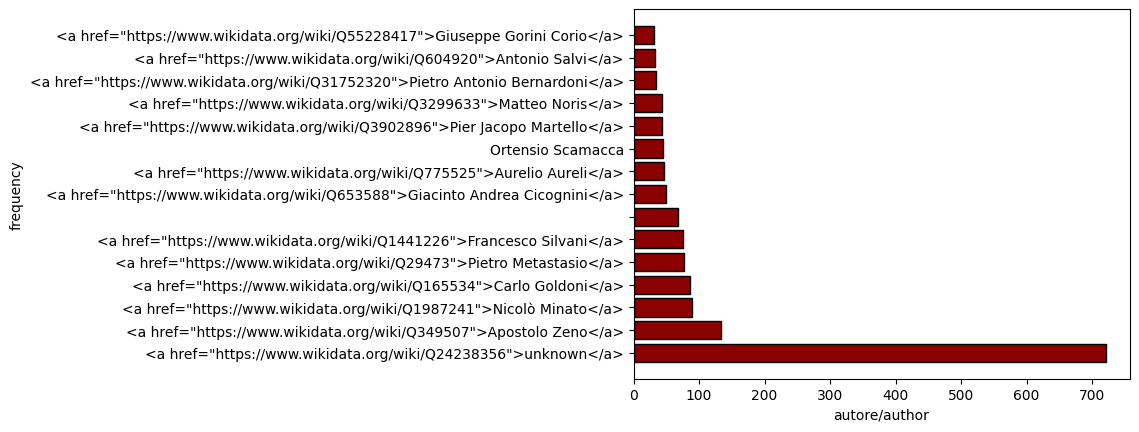

In [37]:
visualise('autore/author',plot_type="barh")

### Author productivity distribution (power-law / Zipf)


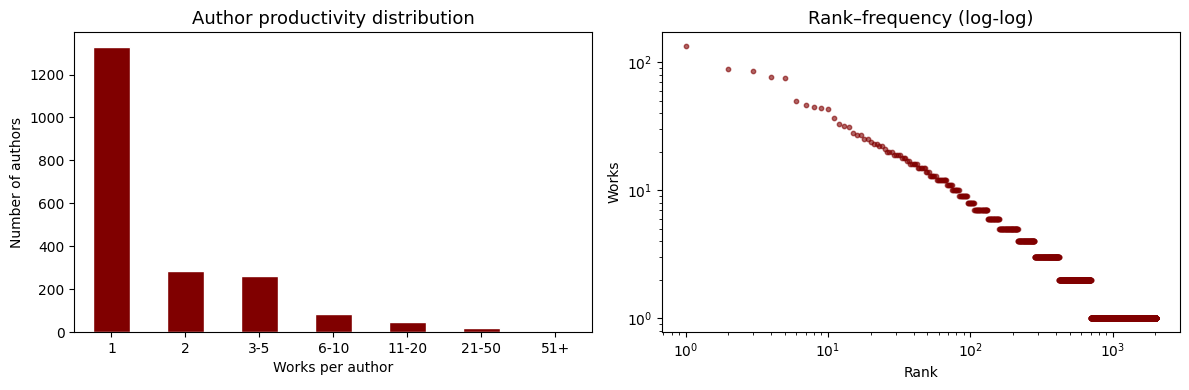

Total named authors: 2,032  |  median works/author: 1  |  max: 134 (Apostolo Zeno)


In [38]:
# --- Author productivity distribution ---
import numpy as np

def _strip_html(s):
    if isinstance(s, str):
        m = re.search(r'<a[^>]*>(.*?)</a>', s)
        return m.group(1) if m else (s.strip() or None)
    return None

works_per_author = (
    df['autore/author'].apply(_strip_html).dropna()
    .pipe(lambda s: s[~s.str.lower().isin(['unknown', ''])])
    .value_counts()
)

bins   = [0, 1, 2, 5, 10, 20, 50, works_per_author.max() + 1]
labels = ['1', '2', '3-5', '6-10', '11-20', '21-50', '51+']
buckets = pd.cut(works_per_author, bins=bins, labels=labels).value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# left: bucket bar chart
buckets.plot(kind='bar', ax=ax1, color='#800000', edgecolor='white')
ax1.set_title('Author productivity distribution', fontsize=13)
ax1.set_xlabel('Works per author')
ax1.set_ylabel('Number of authors')
ax1.tick_params(axis='x', rotation=0)

# right: log-log Zipf plot
ranks = np.arange(1, len(works_per_author) + 1)
ax2.scatter(ranks, works_per_author.values, s=10, color='#800000', alpha=0.6)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_title('Rank–frequency (log-log)', fontsize=13)
ax2.set_xlabel('Rank'); ax2.set_ylabel('Works')

plt.tight_layout()
plt.show()
print(f'Total named authors: {len(works_per_author):,}  |  '
      f'median works/author: {works_per_author.median():.0f}  |  '
      f'max: {works_per_author.max()} ({works_per_author.idxmax()})')


### Publisher × genre specialisation


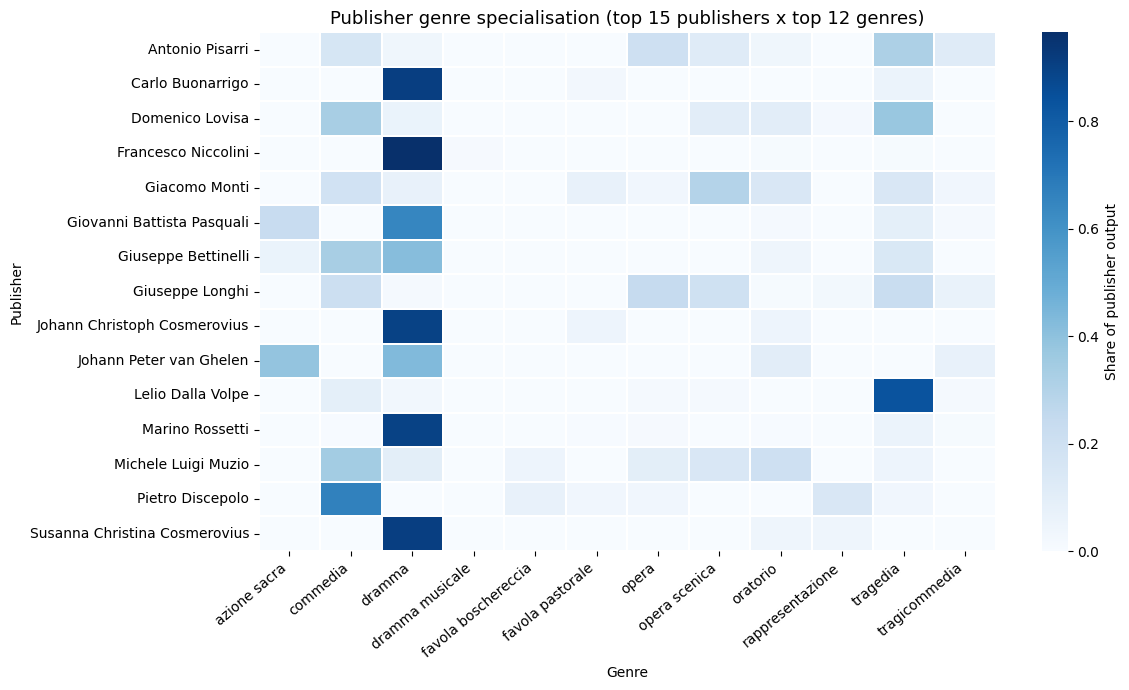

In [39]:
# --- Publisher x genre heatmap (row-normalised) ---
_tmp = df[['editore/publisher', 'genere/genre']].copy()
_tmp['pub']          = _tmp['editore/publisher'].apply(_strip_html)
_tmp['genere/genre'] = _tmp['genere/genre'].apply(_strip_html)
_tmp = _tmp.dropna(subset=['pub', 'genere/genre'])
_tmp = _tmp[~_tmp['pub'].str.lower().isin(['unknown', ''])]
_tmp = _tmp[~_tmp['genere/genre'].str.lower().isin(['unknown', ''])]

top_pubs   = _tmp['pub'].value_counts().head(15).index
top_genres = _tmp['genere/genre'].value_counts().head(12).index
_tmp = _tmp[_tmp['pub'].isin(top_pubs) & _tmp['genere/genre'].isin(top_genres)]

pivot = _tmp.groupby(['pub', 'genere/genre']).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_norm, cmap='Blues', linewidths=0.3, annot=False,
            ax=ax, cbar_kws={'label': 'Share of publisher output'})
ax.set_title('Publisher genre specialisation (top 15 publishers x top 12 genres)', fontsize=13)
ax.set_xlabel('Genre'); ax.set_ylabel('Publisher')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


# 2.x Female authorship

Gender assigned via two sources: (1) Wikidata P21 for QID-linked authors, (2) a list of common Italian female first names of the period as fallback. Cached to `data/author_gender.csv`.


In [4]:
import time, numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

GENDER_CSV = Path('data/author_gender.csv')

# Common Italian female first names, early modern period (1500-1750)
FEMALE_NAMES = {
    'agnese','alessandra','alfonsina','angelica','anna','annunziata',
    'antonia','arcangela','aurelia','barbara','beatrice','bianca',
    'camilla','cassandra','caterina','cecilia','chiara','claudia',
    'clelia','cleopatra','clotilde','cornelia','costanza','cristina',
    'diana','dianora','dorotea','eleonora','elena','emilia','erminia',
    'ersilia','faustina','felice','fiammetta','flaminia','flavia',
    'francesca','ginevra','giovanna','giulia','giustina','grazia',
    'hortensia','ippolita','isabella','isotta','lavinia','laura',
    'leonora','livia','lucrezia','luigia','luisa','maddalena',
    'margherita','maria','marina','marietta','marta','olimpia',
    'ortensia','orsola','ottavia','paola','penelope','porzia',
    'rosa','sabina','silvia','silveria','sofia','susanna',
    'teresa','tullia','ursula','valeria','verdiana','veronica',
    'virginia','vittoria','zanetta',
}

def _strip_html(s):
    if isinstance(s, str):
        m = re.search(r'<a[^>]*>(.*?)</a>', s)
        return m.group(1) if m else s.strip() or None
    return None

def _qid(s):
    m = re.search(r'/wiki/(Q\d+)', s) if isinstance(s, str) else None
    return m.group(1) if m else None

def _gender_by_name(full_name):
    first = full_name.split()[0].lower().rstrip('.')
    return 'female' if first in FEMALE_NAMES else None

# Build unique-author table
authors = (df[['autore/author']]
           .assign(name=df['autore/author'].apply(_strip_html),
                   qid =df['autore/author'].apply(_qid))
           .dropna(subset=['name'])
           .query('name.str.lower() not in ["unknown", ""]')
           .drop_duplicates('name')[['name','qid']].copy())
authors['gender'] = None

# Layer 1: Wikidata P21 for QID-linked authors
qid_rows = authors[authors['qid'].notna()]
qids     = qid_rows['qid'].tolist()
wd_gender = {}
batches   = [qids[i:i+50] for i in range(0, len(qids), 50)]
for batch in tqdm(batches, desc='Wikidata P21'):
    sparql = ('SELECT ?p ?gL WHERE{VALUES ?p{'
              + ' '.join(f'wd:{q}' for q in batch)
              + '}?p wdt:P21 ?g.'
              'SERVICE wikibase:label{bd:serviceParam wikibase:language"en".}'
              '?g rdfs:label ?gL.FILTER(LANG(?gL)="en")}')
    try:
        r = requests.get('https://query.wikidata.org/sparql',
                         params={'query': sparql},
                         headers={'Accept':'application/sparql-results+json',
                                  'User-Agent':'AllacciDigitale/1.0'},
                         timeout=15)
        r.raise_for_status()
        for row in r.json()['results']['bindings']:
            q   = row['p']['value'].split('/')[-1]
            lbl = row['gL']['value'].lower()
            wd_gender[q] = 'female' if 'female' in lbl else 'male'
    except Exception as e:
        tqdm.write(f'  batch failed: {e}')
    time.sleep(1.1)

qid_to_name = qid_rows.set_index('qid')['name'].to_dict()
for q, g in wd_gender.items():
    if q in qid_to_name:
        authors.loc[authors['name'] == qid_to_name[q], 'gender'] = g
print(f'Wikidata: {len(wd_gender)} authors resolved ({sum(v=="female" for v in wd_gender.values())} female)')

# Layer 2: first-name lookup for remaining unresolved authors
mask = authors['gender'].isna()
authors.loc[mask, 'gender'] = authors.loc[mask, 'name'].apply(_gender_by_name)
print(f'First-name lookup added {authors.loc[mask, "gender"].notna().sum()} more')

authors.to_csv(GENDER_CSV, index=False)
df['author_name']   = df['autore/author'].apply(_strip_html)
df['author_gender'] = df['author_name'].map(authors.set_index('name')['gender'])

female = sorted(authors[authors['gender']=='female']['name'])
print(f'\nTotal unique authors: {len(authors)} | resolved: {authors["gender"].notna().sum()}')
print(f'Female authors identified ({len(female)}): {chr(10)}  ' + chr(10).join(f'  {n}' for n in female))


Wikidata P21:   0%|          | 0/14 [00:00<?, ?it/s]

Wikidata: 651 authors resolved (14 female)
First-name lookup added 10 more

Total unique authors: 2032 | resolved: 661
Female authors identified (24): 
    Antonia Fontana
  Antonia Tanini Pulci
  Brigida Bianchi
  Felice Arduini
  Francesca Manzoni
  Giovanna di Benedetto
  Giulia Rangona
  Isabella Andreini
  Isabella Mestrilli
  Isabetta Coreglia
  Laura Guidiccioni
  Luigia Joèle
  Luisa Bergalli
  Maddalena Campiglia
  Margherita Costa
  Maria Clemente Ruoti
  Maria Costanza Pavin
  Maria Isabella Clementini Liberati
  Maria Isabella Dosi Grati
  Moderata Fonte
  Orsola Biancolelli
  Susanna Christina Cosmerovius
  Valeria Miani
  Veronica Maleguzzi Valeri


In [5]:
# Works by female authors
_female_works = (
    df[df['author_gender'] == 'female']
    [['anno/year', 'author_name', 'titolo/title', 'genere/genre', 'luogo di pubblicazione/city']]
    .assign(**{
        'genere/genre':                  lambda d: d['genere/genre'].apply(_strip_html),
        'luogo di pubblicazione/city':   lambda d: d['luogo di pubblicazione/city'].apply(_strip_html),
    })
    .sort_values(['author_name', 'anno/year'])
    .reset_index(drop=True)
)

print(f'{len(_female_works)} works by {_female_works["author_name"].nunique()} female authors:\n')
for author, group in _female_works.groupby('author_name'):
    print(f'  {author} ({len(group)} works)')
    for _, row in group.iterrows():
        year  = int(row['anno/year']) if row['anno/year'] > 0 else '?'
        genre = row['genere/genre'] or ''
        city  = row['luogo di pubblicazione/city'] or ''
        print(f'    {year}  {row["titolo/title"]}  [{genre}, {city}]')
    print()


62 works by 24 female authors:

  Antonia Fontana (1 works)
    1680  Erginda  [dramma, Piazzola sul Brenta]

  Antonia Tanini Pulci (3 works)
    ?  Francesco  [rappresentazione, Siena]
    ?  Santa Guglielma  [rappresentazione, Siena]
    1591  Figliuol Prodigo  [rappresentazione, nan]

  Brigida Bianchi (1 works)
    1659  Inganno Fortunato  [commedia bellissima, Paris]

  Felice Arduini (1 works)
    1634  Spettacoli D'Amore  [commedia rusticale, Arezzo]

  Francesca Manzoni (2 works)
    1733  Ester  [tragedia, Verona]
    1751  Ester  [tragedia, Venice]

  Giovanna di Benedetto (3 works)
    ?  Rosilla  [favola boschereccia, Naples]
    1687  Fedeltà Ingegnosa  [nan, Bologna]
    1687  Viva Sepoltura  [opera, Bologna]

  Giulia Rangona (1 works)
    ?  Giustizia Placata  [oratorio, Cremona]

  Isabella Andreini (1 works)
    1588  Mirtilla  [favola pastorale, Verona]

  Isabella Mestrilli (1 works)
    1703  Prodigio Della Bellezza  [commedia, Naples]

  Isabetta Coreglia (2 work

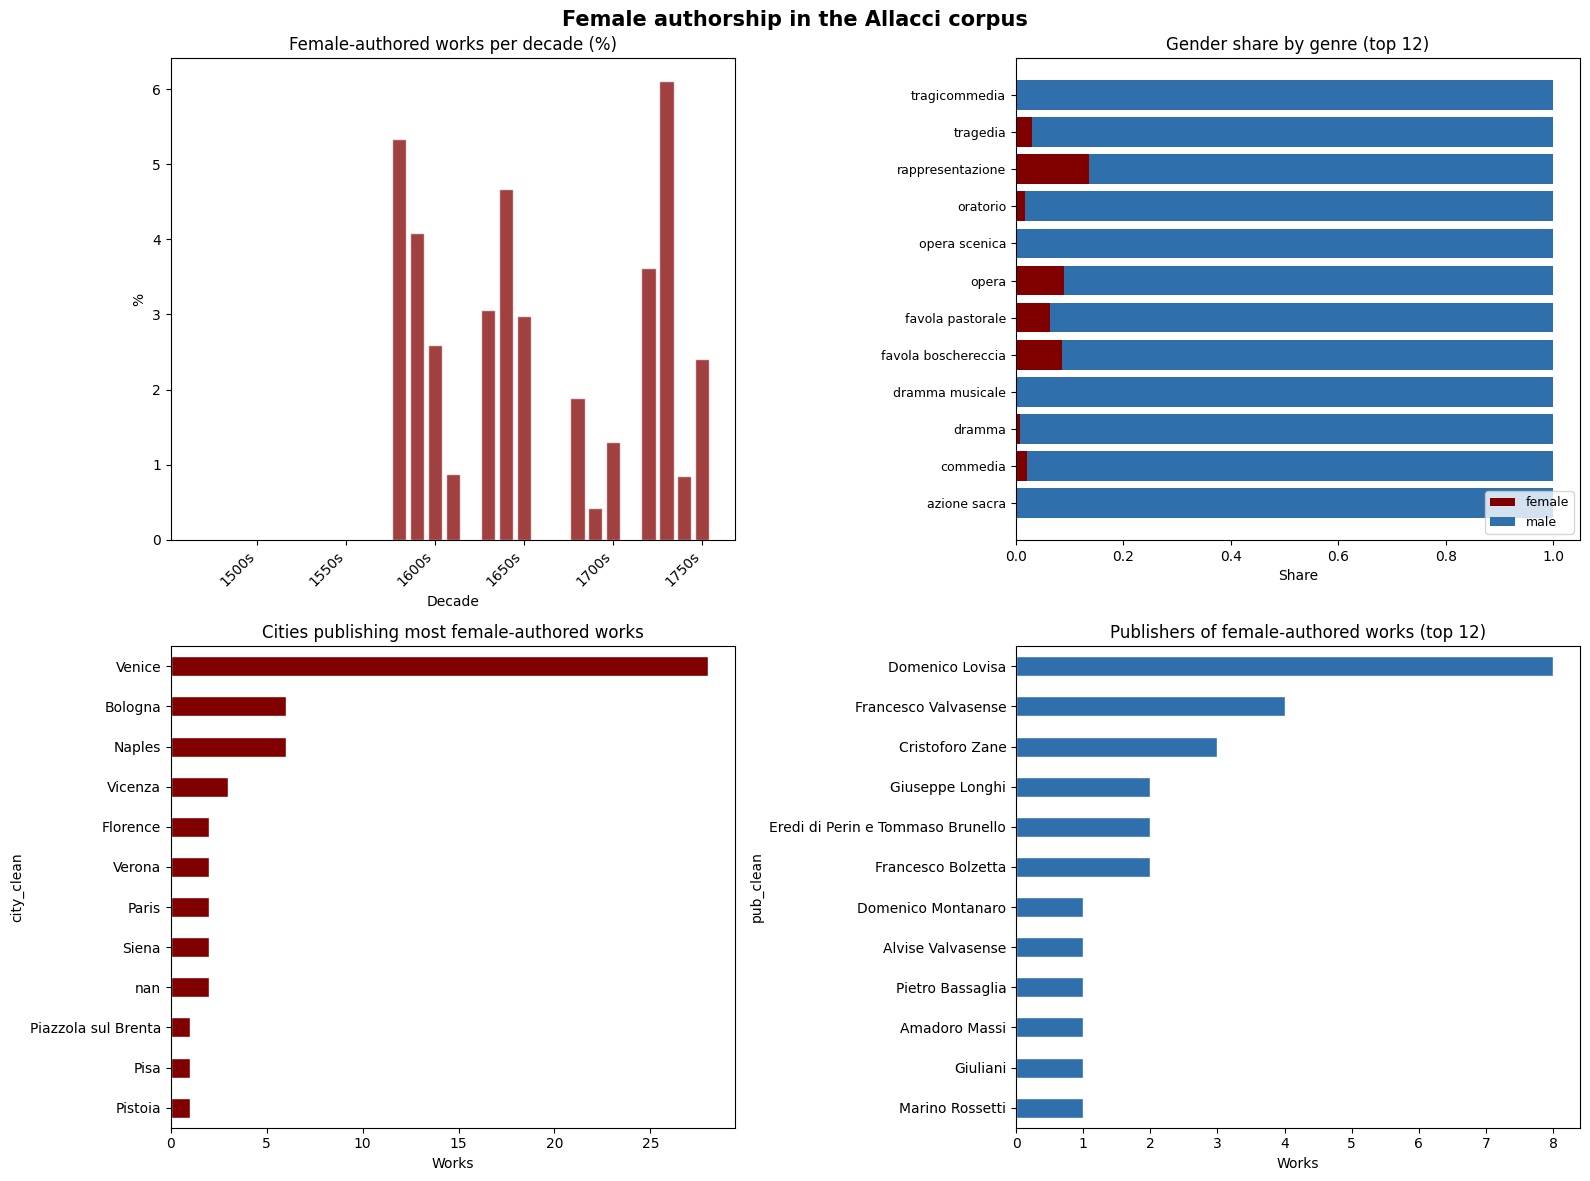

Female-authored: 62 works / 3052 with known gender (2.0%)
Anonymous: 0 works (excluded)


In [50]:
_f = df[df['author_gender'].notna()].copy()
_f['decade']      = (_f['anno/year'].where(_f['anno/year'] > 0) // 10 * 10).dropna().astype(int)
_f['genre_clean'] = _f['genere/genre'].apply(_strip_html)
_f['city_clean']  = _f['luogo di pubblicazione/city'].apply(_strip_html)
_f['pub_clean']   = _f['editore/publisher'].apply(_strip_html)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Female authorship in the Allacci corpus', fontsize=15, fontweight='bold')
COLORS = {'female':'#800000','male':'#2e6fac','other':'#aaaaaa'}

# 1. Female share per decade
ax = axes[0,0]
_d = _f[_f['decade'].notna()]
share = (_d[_d['author_gender']=='female'].groupby('decade').size()
         / _d.groupby('decade').size() * 100).fillna(0)
ax.bar(share.index, share.values, width=8, color='#800000', alpha=0.75, edgecolor='white')
ax.set(title='Female-authored works per decade (%)', xlabel='Decade', ylabel='%')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x)}s'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 2. Gender share by genre
ax = axes[0,1]
_g = _f[_f['genre_clean'].notna() & ~_f['genre_clean'].str.lower().isin(['unknown',''])]
top_g = _g['genre_clean'].value_counts().head(12).index
piv = (_g[_g['genre_clean'].isin(top_g)]
       .groupby(['genre_clean','author_gender']).size()
       .unstack(fill_value=0)
       .pipe(lambda p: p.div(p.sum(axis=1), axis=0)))
bottom = np.zeros(len(piv))
for g in ['female','male','other']:
    if g in piv.columns:
        ax.barh(range(len(piv)), piv[g], left=bottom, color=COLORS[g], label=g)
        bottom += piv[g].values
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=9)
ax.set(title='Gender share by genre (top 12)', xlabel='Share')
ax.legend(loc='lower right', fontsize=9)

# 3. Cities publishing most female-authored works
ax = axes[1,0]
(_f[(_f['author_gender']=='female') & _f['city_clean'].notna()
    & ~_f['city_clean'].str.lower().isin(['unknown',''])]
 ['city_clean'].value_counts().head(12).sort_values()
 .plot(kind='barh', ax=ax, color='#800000', edgecolor='white'))
ax.set(title='Cities publishing most female-authored works', xlabel='Works')

# 4. Publishers of female-authored works
ax = axes[1,1]
(_f[(_f['author_gender']=='female') & _f['pub_clean'].notna()
    & ~_f['pub_clean'].str.lower().isin(['unknown',''])]
 ['pub_clean'].value_counts().head(12).sort_values()
 .plot(kind='barh', ax=ax, color='#2e6fac', edgecolor='white'))
ax.set(title='Publishers of female-authored works (top 12)', xlabel='Works')

plt.tight_layout(); plt.show()

n_f = (df['author_gender']=='female').sum()
n_k = df['author_gender'].notna().sum()
print(f'Female-authored: {n_f} works / {n_k} with known gender ({100*n_f/n_k:.1f}%)')
print(f'Anonymous: {df["autore/author"].isna().sum()} works (excluded)')


In [ ]:
2.x # --- Map of performance locations (luogo di rappresentazione) ---

In [51]:

import time, numpy as np
from pathlib import Path

PERF_CSV = Path('data/performance_counts.csv')

def _strip_loc(s):
    if isinstance(s, str):
        m = re.search(r'<a[^>]*>(.*?)</a>', s)
        return m.group(1).strip() if m else s.strip()
    return None

# Build counts from the main df
perf_counts = (
    df['luogo di rappresentazione/location']
    .apply(_strip_loc)
    .dropna()
    .pipe(lambda s: s[~s.str.lower().isin(['unknown', ''])])
    .value_counts()
    .reset_index()
)
perf_counts.columns = ['city-name', 'counts']

# Geocode with cache (same pattern as publication cities)
if PERF_CSV.exists():
    perf_geo = pd.read_csv(PERF_CSV)
    perf_geo['Latitude']  = pd.to_numeric(perf_geo['Latitude'],  errors='coerce')
    perf_geo['Longitude'] = pd.to_numeric(perf_geo['Longitude'], errors='coerce')
    # Merge in any new cities not yet geocoded
    known = set(perf_geo['city-name'])
    new_cities = perf_counts[~perf_counts['city-name'].isin(known)]
    if not new_cities.empty:
        new_cities = new_cities.copy()
        new_cities['Latitude'] = np.nan
        new_cities['Longitude'] = np.nan
        perf_geo = pd.concat([perf_geo, new_cities], ignore_index=True)
    # Update counts from live data
    count_map = perf_counts.set_index('city-name')['counts'].to_dict()
    perf_geo['counts'] = perf_geo['city-name'].map(count_map).fillna(perf_geo['counts'])
    pending = perf_geo[perf_geo['Latitude'].isna()]
else:
    PERF_CSV.parent.mkdir(parents=True, exist_ok=True)
    perf_geo = perf_counts.copy()
    perf_geo['Latitude']  = np.nan
    perf_geo['Longitude'] = np.nan
    perf_geo.to_csv(PERF_CSV, index=False)
    pending = perf_geo

if not pending.empty:
    print(f'Geocoding {len(pending)} performance cities...')
    for idx_row, row in pending.iterrows():
        city = row['city-name']
        try:
            time.sleep(1.1)
            loc = geolocator.geocode(city)
            perf_geo.loc[idx_row, 'Latitude']  = float(loc.latitude)  if loc else np.nan
            perf_geo.loc[idx_row, 'Longitude'] = float(loc.longitude) if loc else np.nan
        except Exception as e:
            print(f'  [{city}] failed: {e}')
            perf_geo.loc[idx_row, 'Latitude']  = np.nan
            perf_geo.loc[idx_row, 'Longitude'] = np.nan
        perf_geo.to_csv(PERF_CSV, index=False)
    print('Done.')
else:
    print(f'Loaded {len(perf_geo)} performance cities from cache.')

# Plot
perf_mapped = perf_geo[perf_geo['Latitude'].notna() & perf_geo['Longitude'].notna()]
m_perf = folium.Map(location=[44.0, 12.0], zoom_start=5)
for _, row in perf_mapped.iterrows():
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),
        radius=max(4, row['counts'] / 40),
        color='steelblue', fill=True, fill_color='steelblue', fill_opacity=0.5,
        popup=f"{row['city-name']}: {int(row['counts'])} performances"
    ).add_to(m_perf)
print(f'Showing {len(perf_mapped)} cities ({perf_mapped["counts"].sum():.0f} performances total)')
m_perf


Geocoding 112 performance cities...
Done.
Showing 41 cities (673 performances total)


### 2.3 Diachronic overview (histogram)

> Working DataFrame: filtered to rows where `anno/year != 0`.

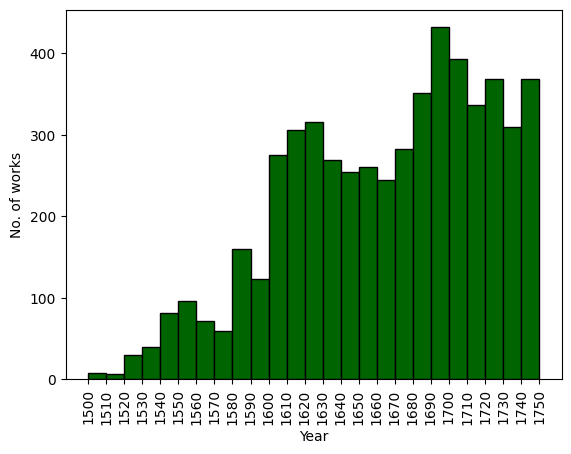

In [41]:
# print the corpus' diachronic span

filtered_df = df[df['anno/year'].notna() & (df['anno/year'] != 0)]

# Plot histogram
plt.hist(filtered_df['anno/year'], bins=range(1500, 1760, 10), color="darkgreen", edgecolor='black')

# Set major labels every 50 years
major_labels = range(1500, 1760, 10)
plt.xticks(major_labels, rotation=90)

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('No. of works')

# Show the plot
plt.show()

### Genre × decade heatmap


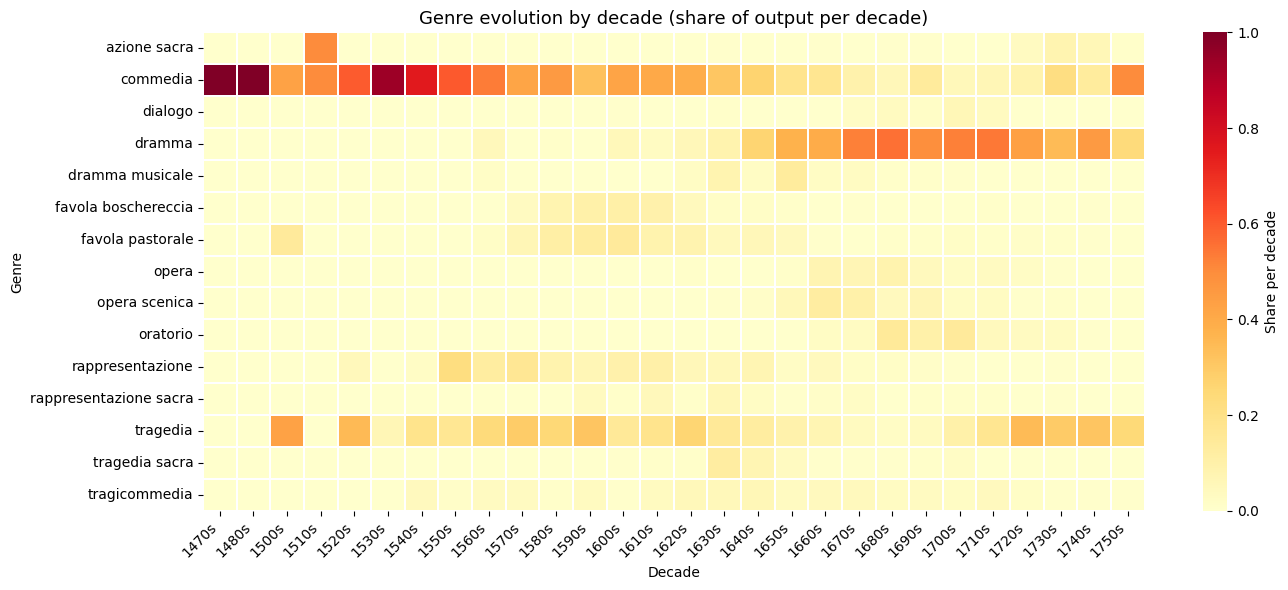

In [42]:
# --- Genre x decade heatmap ---
_tmp = df[(df['anno/year'] > 0)].copy()
_tmp['decade'] = (_tmp['anno/year'] // 10 * 10).astype(str) + 's'
_tmp['genre_clean'] = _tmp['genere/genre'].apply(_strip_html)
_tmp = _tmp[~_tmp['genre_clean'].str.lower().isin(['unknown', ''])]
_tmp = _tmp.dropna(subset=['genre_clean'])

top_genres = _tmp['genre_clean'].value_counts().head(15).index
_tmp = _tmp[_tmp['genre_clean'].isin(top_genres)]

pivot = (_tmp.groupby(['decade', 'genre_clean']).size()
         .unstack(fill_value=0))
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)   # row-normalised

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_norm.T, cmap='YlOrRd', linewidths=0.3, annot=False,
            ax=ax, cbar_kws={'label': 'Share per decade'})
ax.set_title('Genre evolution by decade (share of output per decade)', fontsize=13)
ax.set_xlabel('Decade'); ax.set_ylabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Geographic spread over time


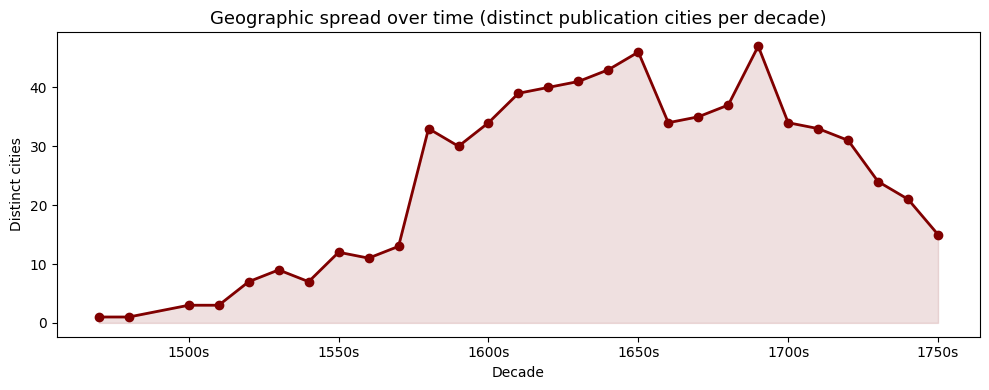

In [43]:
# --- Distinct publication cities per decade ---
_tmp = df[(df['anno/year'] > 0)].copy()
_tmp['decade'] = (_tmp['anno/year'] // 10) * 10
_tmp['city_clean'] = _tmp['luogo di pubblicazione/city'].apply(_strip_html)
_tmp = _tmp[~_tmp['city_clean'].str.lower().isin(['unknown', ''])]
_tmp = _tmp.dropna(subset=['city_clean'])

city_spread = _tmp.groupby('decade')['city_clean'].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(city_spread.index, city_spread.values, color='#800000', marker='o', linewidth=2)
ax.fill_between(city_spread.index, city_spread.values, alpha=0.12, color='#800000')
ax.set_title('Geographic spread over time (distinct publication cities per decade)', fontsize=13)
ax.set_xlabel('Decade'); ax.set_ylabel('Distinct cities')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.tight_layout()
plt.show()


### City × genre correlation


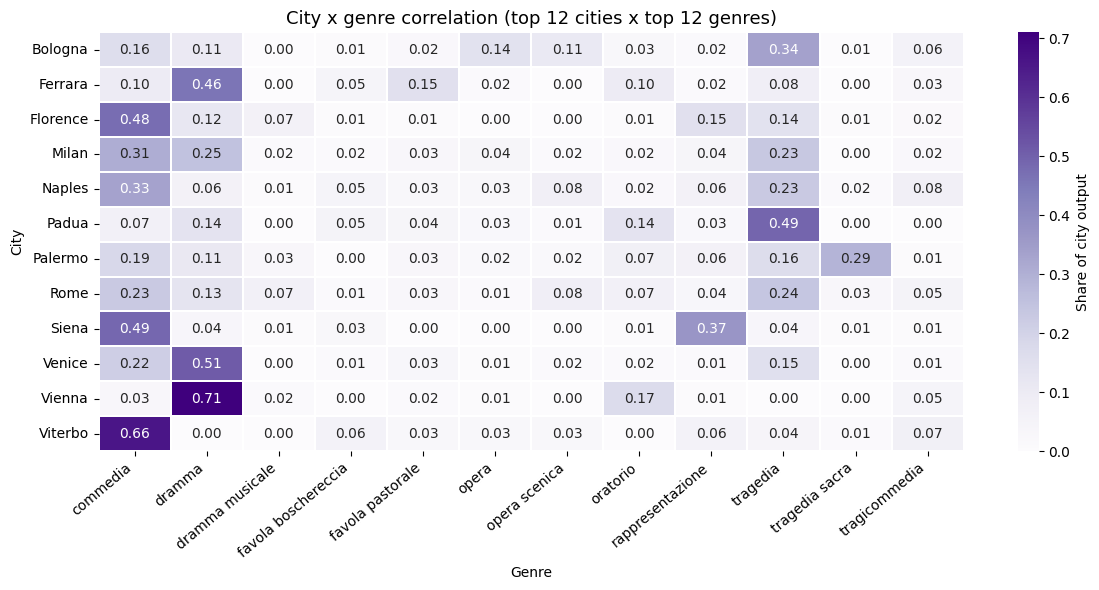

In [44]:
# --- City x genre heatmap (row-normalised) ---
_tmp = df[['luogo di pubblicazione/city', 'genere/genre']].copy()
_tmp['city_clean']   = _tmp['luogo di pubblicazione/city'].apply(_strip_html)
_tmp['genre_clean']  = _tmp['genere/genre'].apply(_strip_html)
_tmp = _tmp.dropna(subset=['city_clean', 'genre_clean'])
_tmp = _tmp[~_tmp['city_clean'].str.lower().isin(['unknown', ''])]
_tmp = _tmp[~_tmp['genre_clean'].str.lower().isin(['unknown', ''])]

top_cities = _tmp['city_clean'].value_counts().head(12).index
top_genres  = _tmp['genre_clean'].value_counts().head(12).index
_tmp = _tmp[_tmp['city_clean'].isin(top_cities) & _tmp['genre_clean'].isin(top_genres)]

pivot = _tmp.groupby(['city_clean', 'genre_clean']).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_norm, cmap='Purples', linewidths=0.3, annot=True, fmt='.2f',
            ax=ax, cbar_kws={'label': 'Share of city output'})
ax.set_title('City x genre correlation (top 12 cities x top 12 genres)', fontsize=13)
ax.set_xlabel('Genre'); ax.set_ylabel('City')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


Let's explore correlation of authors and printers

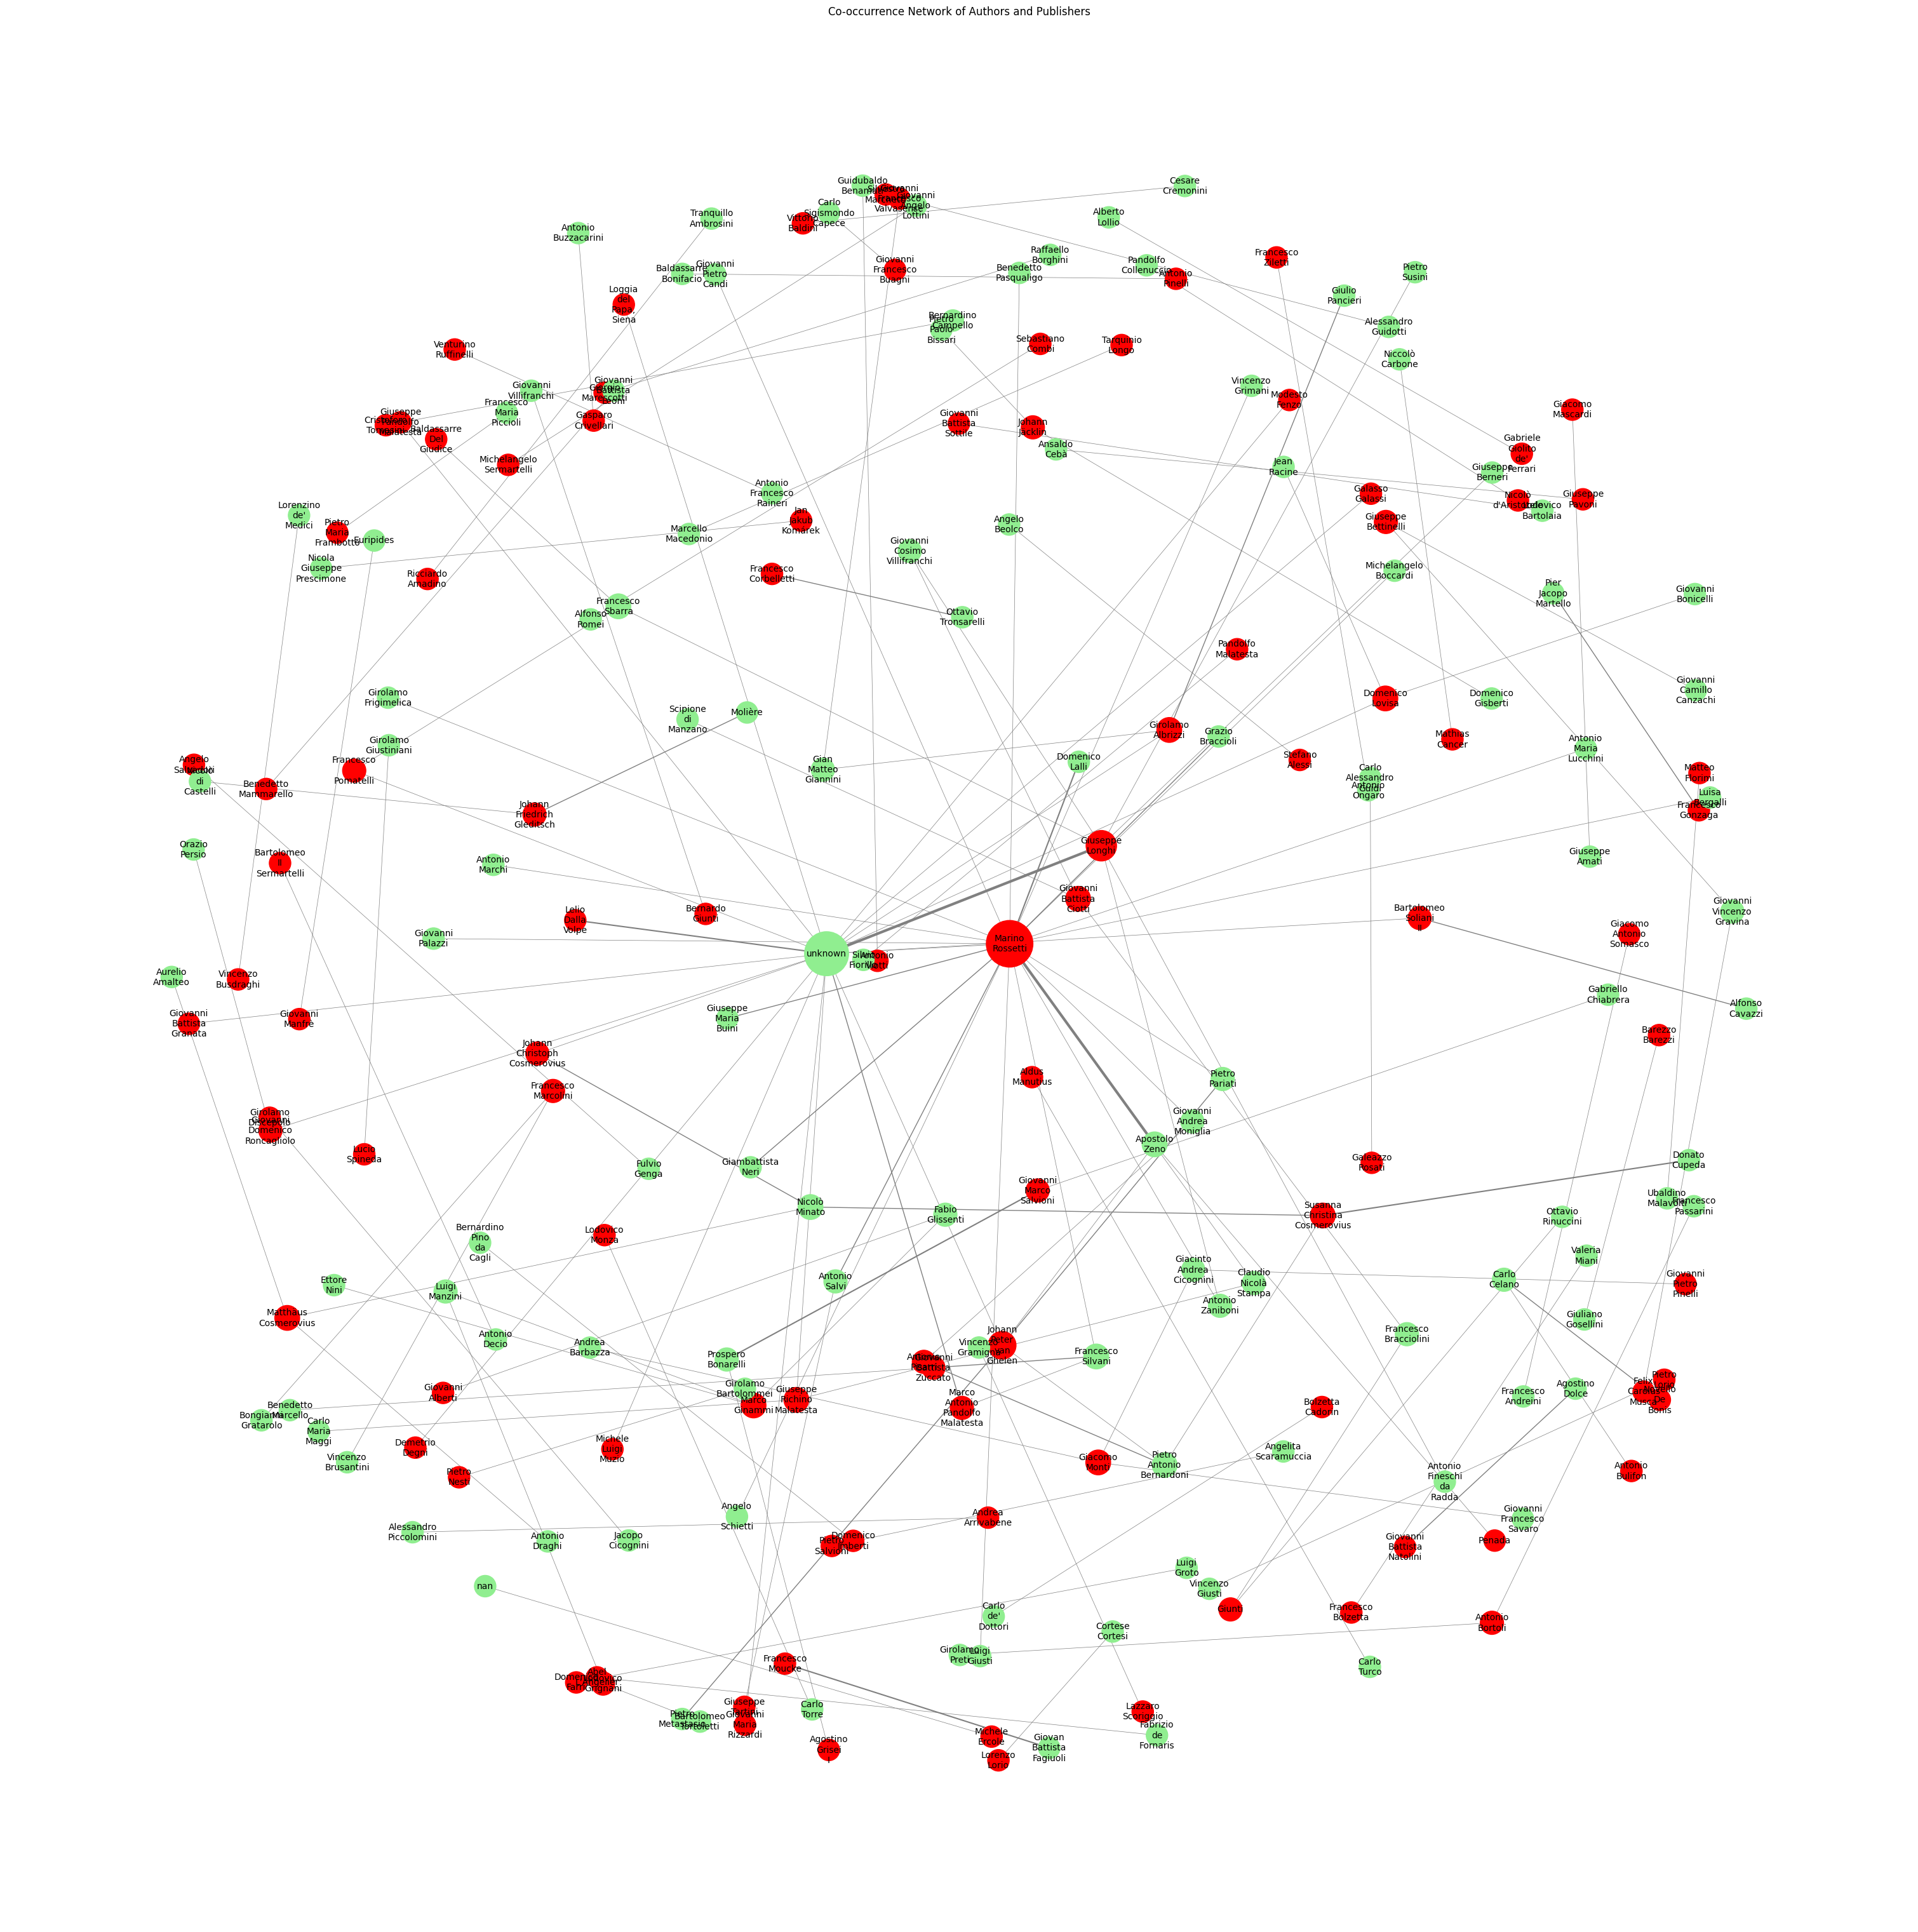

In [45]:
# Function to extract text from HTML anchor tags
new_df = df.copy()

# Function to extract text from HTML anchor tags
def extract_html_text(text):
    if isinstance(text, str) and '<a href=' in text:
        match = re.search(r'<a href="[^"]*">(.*?)</a>', text)
        if match:
            return match.group(1)  # Extract the text between the tags
    return None  # Return None if not wrapped in HTML

# Apply the function to the columns
new_df['autore/author'] = new_df['autore/author'].apply(extract_html_text)
new_df['editore/publisher'] = new_df['editore/publisher'].apply(extract_html_text)

# Filter out rows where either author or publisher is None
new_df = new_df[new_df['autore/author'].notnull() & new_df['editore/publisher'].notnull()]

# Build the co-occurrence network
graph = nx.Graph()

# Add edges and nodes to the graph with appropriate colors
for index, row in new_df.head(200).iterrows():
    author = row['autore/author']
    publisher = row['editore/publisher']
    graph.add_node(author, type='author')  # Add author node
    graph.add_node(publisher, type='publisher')  # Add publisher node
    graph.add_edge(author, publisher, weight=graph[author][publisher]['weight'] + 1 if graph.has_edge(author, publisher) else 1)

# Visualize the network
pos = nx.spring_layout(graph, k=0.5)  # Use a layout to minimize overlap

# Prepare node colors based on type
node_colors = ['lightgreen' if graph.nodes[node]['type'] == 'author' else 'red' for node in graph.nodes()]

# Calculate node sizes based on degree
node_sizes = [500 + graph.degree(node) * 100 for node in graph.nodes()]  # Scale sizes

# Edge widths based on weights
edge_widths = [data['weight'] * 0.5 for _, _, data in graph.edges(data=True)]

# Prepare labels with line breaks
labels = {node: node.replace(' ', '\n') for node in graph.nodes()}

# Draw the graph
plt.figure(figsize=(30, 30))

# Draw nodes and edges
nx.draw(graph, pos, node_color=node_colors, node_size=node_sizes, edge_color='gray', width=edge_widths)

# Manually position labels to reduce overlap
for node in graph.nodes():
    x, y = pos[node]
    plt.text(x, y, labels[node], fontsize=10, ha='center', va='center',
             bbox=dict(facecolor='none', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.3'))

plt.title('Co-occurrence Network of Authors and Publishers')
plt.axis('off')  # Hide axes
plt.show()

In [46]:
# Create a new DataFrame with the desired format
authors = new_df['autore/author'].apply(lambda x: (x, 'author'))
publishers = new_df['editore/publisher'].apply(lambda x: (x, 'publisher'))

# Combine authors and publishers into a single DataFrame
combined = pd.DataFrame(authors.tolist(), columns=['Name', 'Label'])
combined = pd.concat([combined, pd.DataFrame(publishers.tolist(), columns=['Name', 'Label'])], ignore_index=True)

# Save the combined DataFrame as a CSV file
combined.to_csv('authors_publishers.csv', index=False)

## 4. Title Analysis

In [ ]:
import subprocess, sys
for _model in ['it_core_news_sm', 'it_core_news_lg']:
    try:
        __import__('spacy').load(_model)
        print(f'{_model} already installed, skipping download.')
    except OSError:
        subprocess.run([sys.executable, '-m', 'spacy', 'download', _model], check=True)


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'stanza', 'gender-guesser'], check=True)
import stanza
import gender_guesser.detector as gender

# Download Italian model only if not already present
stanza.download('it', verbose=False)
# Note: nlp pipeline is created later in section 4.4 with lightweight processors only


In [ ]:
from pathlib import Path
import requests

_names_cache = Path('data/italian_names.txt')
_words_cache = Path('data/italian_words.txt')

if _names_cache.exists():
    italian_names = _names_cache.read_text(encoding='utf-8').splitlines()
else:
    _url = 'https://gist.githubusercontent.com/allanlewis/ddfe6e7053fd12986589c52edf6ef856/raw/bc6ca7a55527930ec5f25e448c3aa0a7deee2de6/italian-first-names.txt'
    italian_names = requests.get(_url).text.split('\n')
    _names_cache.parent.mkdir(parents=True, exist_ok=True)
    _names_cache.write_text('\n'.join(italian_names), encoding='utf-8')
italian_names = [n.lower() for n in italian_names if n.strip()]

if _words_cache.exists():
    italian_words = _words_cache.read_text(encoding='utf-8').splitlines()
else:
    _url2 = 'https://raw.githubusercontent.com/napolux/paroleitaliane/refs/heads/master/paroleitaliane/60000_parole_italiane.txt'
    italian_words = requests.get(_url2).text.split('\n')
    _words_cache.write_text('\n'.join(italian_words), encoding='utf-8')
italian_words = [w.strip() for w in italian_words if w.strip()]

print(f'Italian names loaded: {len(italian_names)}')
print(f'Italian words loaded: {len(italian_words)}')


In [ ]:
from pathlib import Path
import pandas as pd

_db_cache = Path("data/database_cache.json")
_db_url   = "https://raw.githubusercontent.com/allacci-digitale/allacci-digitale.github.io/main/data/database.json"

if _db_cache.exists():
    df = pd.read_json(_db_cache)
    print(f"Loaded df from local cache ({len(df)} rows).")
else:
    df = pd.read_json(_db_url)
    _db_cache.parent.mkdir(parents=True, exist_ok=True)
    df.to_json(_db_cache, orient="records", force_ascii=False)
    print(f"Fetched df from GitHub and cached locally ({len(df)} rows).")

df.head(1)


### 4.1 Text preprocessing

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"d\'", " ", text)  # Remove 'd' '
    #text = re.sub(r'\(', '', text)  # Remove '('
    text = re.sub(r',', '', text)  # Remove commas
    text = text.strip()
    # Remove Italian stop words
    italian_stop_words = set(stopwords.words('italian'))
    italian_stop_words.add("de'")
    tokens = [word for word in text.split() if word not in italian_stop_words]
    tokens = [re.sub(r"\'", ' ', token) for token in tokens]
    tokens = [re.sub(r"\(", '', token) for token in tokens]
    tokens = [re.sub(r"\)", '', token) for token in tokens]
    # Remove Italian person names -- were waiting to find a better solution
    #tokens = [word for word in tokens if word not in italian_names and word != 'de\'']

    return ' '.join(tokens)

In [ ]:
# Apply the preprocessing function to the 'titolo/title' column
df['processed_title'] = df['titolo/title'].apply(preprocess_text)

# Create a list of preprocessed titles
processed_titles = df['processed_title'].tolist()

# Create a dictionary to store word counts
word_counts = {}
for title in processed_titles:
    for word in title.split():
        if word not in word_counts:
            word_counts[word] = 0
        word_counts[word] += 1

# Sort the word counts in descending order
sorted_word_counts = dict(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the top 20 most frequent words
for word, count in list(sorted_word_counts.items())[:100]:
    print(f"{word}: {count}")


In [ ]:
genre_counts = df['genere/genre'].value_counts()
pd.set_option('display.max_rows', None)
print(genre_counts)

#### Evolution of the length of titles (in characters)

In [ ]:
# Assuming your dataframe is named 'df'
# and it has columns 'titolo/title' and 'anno/year'

# Remove rows with None or NaN values in the 'anno/year' column
df = df.dropna(subset=['anno/year'])
df = df[df['anno/year'] != 0]

# Calculate the length of each title
df['title_length'] = df['titolo/title'].astype(str).str.len()

# Create the scatter plot
fig = px.scatter(
    df,
    x='anno/year',
    y='title_length',
    hover_data={'titolo/title': True, 'title_length': False},
    labels={'anno/year': 'Year', 'title_length': 'Title Length (characters)', 'titolo/title': 'Title'},
    title='Title Length over Time',
    trendline="lowess"
)

for trace in fig.data:
    if trace.mode == 'lines':  # Identify the trendline trace
        trace.line.color = 'red'  # Change to desired color (e.g., 'red')

# Customize the layout
fig.update_traces(marker=dict(size=6))
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Title Length (characters)',
    template='plotly_white'
)

fig.show()

#### Evolution of the length of titles (in words)

In [ ]:
# Create a list of preprocessed titles
processed_titles = df['processed_title'].tolist()

# Create a dictionary to store word counts
word_counts = {}
for title in processed_titles:
    word_count = len(title.split())
    if word_count not in word_counts:
        word_counts[word_count] = 0
    word_counts[word_count] += 1


sorted_word_counts = dict(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the ranking
for word_count, count in sorted_word_counts.items():
  print(f"Titles with {word_count} words: {count} times")



In [ ]:
# Assuming 'test_df' is your DataFrame and it has columns 'processed_title' and 'anno/year'
test_df = df.copy()

# Sorting the dataframe by year to ensure a proper time series plot
test_df = test_df[test_df['anno/year'] != 0]

# Calculate title length in words (by splitting the title by spaces)
test_df['title_length'] = test_df['processed_title'].apply(lambda x: len(x.split()))

# Group the data by 'anno/year' and calculate the average title length for each year
avg_title_length = test_df.groupby('anno/year')['title_length'].mean().reset_index()

# Set the plot size for better readability
plt.figure(figsize=(20, 6))

# Apply lowess smoothing and plot the overall trend
smoothed_title_length = sm.nonparametric.lowess(avg_title_length['title_length'], avg_title_length['anno/year'], frac=0.3)

# Plot the trendline
plt.plot(smoothed_title_length[:, 0], smoothed_title_length[:, 1], label='Smoothed Trend', marker='o', color='red')

# Add titles and labels
plt.title('Evolution of Average Title Length Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Title Length (Words)', fontsize=14)

# Show legend
plt.legend(title="Trend", fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
# Sorting the dataframe by year to ensure a proper time series plot
# df = test_df['anno/year'] != 0

# Calculate title length in words (by splitting the title by spaces)
df['title_length'] = df['processed_title'].apply(lambda x: len(x.split()))

# Group the data by 'anno/year' and 'title_length', then count the number of titles for each combination
title_counts = df.groupby(['anno/year', 'title_length']).size().reset_index(name='count')

# Identify the 5 most frequent title lengths
top_title_lengths = title_counts.groupby('title_length')['count'].sum().nlargest(5).index

# Set the plot size for better readability
plt.figure(figsize=(20, 6))

# Apply lowess smoothing and plot for each title length
handles = []
for title_len in title_counts['title_length'].unique():
    subset = title_counts[title_counts['title_length'] == title_len]

    # Apply lowess smoothing
    smoothed = sm.nonparametric.lowess(subset['count'], subset['anno/year'], frac=0.3)

    # Plot the smoothed line with markers
    line, = plt.plot(smoothed[:, 0], smoothed[:, 1], label=f'Titoli di {title_len} parola/e', marker='o')
    # Collect handles only for top 5 labels
    if title_len in top_title_lengths:
        handles.append(line)

# Add titles and labels
plt.xlabel('Anno', fontsize=14)
plt.ylabel('Numero di titoli', fontsize=14)

# Add the modified legend with only the top 5 labels
plt.legend(handles=handles, title="Lunghezza dei titoli (top 5)", fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


Is there a correlation between genre and title length?

In [ ]:
test_df['title_length'] = test_df['processed_title'].apply(lambda x: len(x.split()))
# Average title length by genre
title_length_by_genre = test_df.groupby('genere/genre')['title_length'].mean().sort_values()

print("\nAverage title length by genre:")
title_length_by_genre
"""
# Temporal patterns in title lengths and genres
test_df['decade'] = (test_df['anno/year'] // 10 + 1) * 10  # Extract the decade

# Share of n-word titles by century and genre
n = input("No. of words in title to explore:",)
test_df['is_n_words'] = test_df['title_length'] == n

# Aggregation: Share of 2-word titles per genre and century
share_n_words = test_df.groupby(['decade', 'genere/genre'])['is_n_words'].mean().reset_index()

print(f"\nShare of {n}-word titles by century and decade:")
print(share_n_words)
"""

In [ ]:
# Filter for "commedia", "tragedia", and "dramma" genres
commedia_df = df[(df['genere/genre'] == 'commedia') & (df['anno/year'].notna()) & (df['anno/year'] != 0)]
tragedia_df = df[(df['genere/genre'] == 'tragedia') & (df["anno/year"].notna()) & (df["anno/year"] != 0)]
dramma_df = df[(df['genere/genre'] == 'dramma') & (df['anno/year'].notna()) & (df['anno/year'] != 0)]

# Group by year and count occurrences
commedia_counts = commedia_df.groupby('anno/year').size().reset_index(name='counts')
tragedia_counts = tragedia_df.groupby('anno/year').size().reset_index(name='counts')
dramma_counts = dramma_df.groupby('anno/year').size().reset_index(name='counts')

# Apply a simple moving average (SMA) for smoothing
window_size = 5  # You can adjust the window size
commedia_counts['smoothed'] = commedia_counts['counts'].rolling(window=window_size, min_periods=1).mean()
tragedia_counts['smoothed'] = tragedia_counts['counts'].rolling(window=window_size, min_periods=1).mean()
dramma_counts['smoothed'] = dramma_counts['counts'].rolling(window=window_size, min_periods=1).mean()

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(commedia_counts['anno/year'], commedia_counts['smoothed'], label='Commedia (Smoothed)', linewidth=2)
plt.plot(tragedia_counts['anno/year'], tragedia_counts['smoothed'], label='Tragedia (Smoothed)', linewidth=2)
plt.plot(dramma_counts['anno/year'], dramma_counts['smoothed'], label='Dramma (Smoothed)', linewidth=2)

plt.xlabel('Year')
plt.ylabel('Number of Works')
plt.title('Evolution of Generic Labels Over Time (Smoothed)')
plt.legend()
plt.grid(True)
plt.show()

Let's visualise the most frequent words in titles

In [ ]:
# Assuming 'df' and 'processed_titles' are already defined as in the provided code

stop_words = ('dell','l')

# Create a dictionary to store word counts, skipping stopwords
word_counts = {}
for title in processed_titles:
    for word in title.split():
        if word not in stop_words:
            if word not in word_counts:
                word_counts[word] = 0
            word_counts[word] += 1

# Sort the word counts in descending order
sorted_word_counts = dict(sorted(word_counts.items(), key=lambda item: item[1], reverse=True))

# Extract words and counts for the histogram
words = list(sorted_word_counts.keys())[:20]  # Take the top 20 words
counts = list(sorted_word_counts.values())[:20]

# Create the histogram
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Histogram of Most Frequent Words in Titles (excluding stopwords)")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

In [ ]:
sorted_word_counts

In [ ]:
# Prepare the data
labels = list(sorted_word_counts.keys())  # Extract words
values = list(sorted_word_counts.values())  # Extract frequencies

# Ensure both lists are the same length
max_words = 40 #min(len(labels), len(values))  # Optional: Limit to 20 words if needed
labels = labels[:max_words]
values = values[:max_words]

# Create a DataFrame
data = pd.DataFrame({
    'labels': labels,
    'parents': [''] * max_words,  # Single-layer hierarchy
    'values': values
})

# Create the treemap
fig = px.treemap(data, path=['labels'], values='values', color='values',
                 color_continuous_scale='inferno')

# Show the treemap
fig.show()

In [ ]:
# Remove rows where 'anno/year' is NaN or 0
df = df[(df['anno/year'].notna()) & (df['anno/year'] != 0)]

# Convert tokenized titles back to string before applying TfidfVectorizer
df['tokenized_title'] = df['processed_title'].apply(word_tokenize)

# Create a function to calculate average pairwise cosine similarity
def avg_pairwise_similarity(titles):
    # Join the tokenized titles back into a string
    titles_as_strings = [" ".join(title) for title in titles]

    # Convert titles to TF-IDF vectors
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(titles_as_strings)

    # Calculate pairwise cosine similarity
    cosine_sim = cosine_similarity(tfidf_matrix)

    # We want the average similarity of all pairs, excluding the diagonal
    num_titles = len(titles_as_strings)
    triu_indices = np.triu_indices(num_titles, k=1)
    avg_similarity = np.mean(cosine_sim[triu_indices])
    return avg_similarity

# Group by 5-year bins and calculate the average pairwise similarity
df['year_bin'] = (df['anno/year'] // 10) * 10  # Create 5-year bins

# Remove bins that correspond to years with no data (e.g., 0 or NaN values)
df = df[df['year_bin'] > 0]

diversification_scores = []

for year_bin in df['year_bin'].unique():
    titles_in_bin = df[df['year_bin'] == year_bin]['tokenized_title'].tolist()
    if len(titles_in_bin) > 1:  # Only calculate if there are more than 1 title
        diversification_scores.append((year_bin, avg_pairwise_similarity(titles_in_bin)))

# Convert the diversification scores into a DataFrame
diversification_df = pd.DataFrame(diversification_scores, columns=['Year Bin', 'Diversification Score'])

# Plot the bar chart of diversification scores
plt.figure(figsize=(12, 6))
plt.bar(diversification_df['Year Bin'], diversification_df['Diversification Score'], color='skyblue', edgecolor='black')
plt.title('Diversification of Titles Over Time (5-Year Bins)')
plt.xlabel('Year (5-Year Bins)')
plt.ylabel('Diversification Score (Avg Pairwise Similarity)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df.head()

### 4.3 Word frequency

In [ ]:
# Step 1: Define a dictionary to group words with different spellings
word_grouping = {
    'amore': 'amor-', 'amori': 'amor-', 'amor': 'amor-', 'amoroso': 'amor-', 'amorosa': 'amor-',
    'san': 'san-', 'san-': 'san-', 'santa': 'san-',
    'trionfante': 'trionf-', 'trionfo': 'trionf-'
}

# Step 2: Split titles into words and replace them based on the dictionary
def replace_variants(word):
    return word_grouping.get(word, word)  # Replace word if in dictionary, otherwise keep it unchanged

# Explode the titles into individual words and apply the mapping
all_words = df['processed_title'].str.split().explode().apply(replace_variants)

# Count the word frequencies after applying the grouping
word_counts = Counter(all_words)

# Step 3: Filter for frequent words (appear more than 30 times)
frequent_words = {word for word, count in word_counts.items() if count > 30}

# Step 4: Modify to aggregate by decade
df['decade'] = (df['anno/year'] // 10) * 10

df = df[(df['anno/year'] >= 1500) & (df['anno/year'] <= 1750)].copy()

# Modify to aggregate by decade
df['decade'] = (df['anno/year'] // 10) * 10

# Explode titles and apply mapping as before
exploded_df = df[['decade', 'processed_title']].copy()
exploded_df['words'] = df['processed_title'].str.split().apply(lambda x: [replace_variants(w) for w in x])
exploded_df = exploded_df.explode('words')

# Filter for frequent words
filtered_df = exploded_df[exploded_df['words'].isin(frequent_words)]

# Count occurrences by decade and word
word_decade_counts = filtered_df.groupby(['decade', 'words']).size().unstack(fill_value=0)

# Apply a moving average smoothing technique
smoothed_word_decade_counts = word_decade_counts.rolling(window=3, min_periods=1).mean()

# Count total number of entries per decade for the secondary axis
entries_per_decade = df.groupby('decade').size()

# Step 7: Plotting with moving average smoothing
fig, ax1 = plt.subplots(figsize=(16, 6))

# Plotting the number of entries as a bar graph
ax1.bar(entries_per_decade.index, entries_per_decade, color='lightgray', alpha=0.5, label='Number of Entries', width=8)

# Create a second y-axis for the smoothed frequencies
ax2 = ax1.twinx()

# Define list of words to exclude and top 10 words for the legend
noprint = ['l', 'dell']  # Replace with your words to exclude
top_10_words = smoothed_word_decade_counts.sum().nlargest(10).index

# Plotting smoothed word frequencies
for word in smoothed_word_decade_counts.columns:
    if word not in noprint and word in top_10_words:
        # Get the decade's data (decade and counts)
        decade = smoothed_word_decade_counts.index
        counts = smoothed_word_decade_counts[word]

        # Plot the smoothed line
        ax2.plot(decade, counts, marker='', label=word)

# Linear scale
ax2.set_yscale('linear')

# Add titles and labels
ax1.set_xlabel('Decade')
ax1.set_ylabel('Numero di opere', color='black')
ax2.set_ylabel('Frequenza livellata', color='black')
ax1.grid(True)

# Clean up the legend
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


Here's a network of the most frequently associated words.

In [ ]:
from itertools import combinations

# Step 1: Count word frequencies
word_counter = Counter()
for title in processed_titles:
    words = title.split()
    word_counter.update(words)

# Step 2: Filter most frequent words
N = 200
most_common_words = set([word for word, count in word_counter.most_common(N)])

# Step 3: Build co-occurrence matrix
co_occurrence_counter = Counter()
for title in processed_titles:
    words = title.split()
    filtered_words = [word for word in words if word in most_common_words]
    co_occurrences = combinations(filtered_words, 2)
    co_occurrence_counter.update(co_occurrences)

# Step 4: Create the graph
G = nx.Graph()
for (word1, word2), count in co_occurrence_counter.items():
    if count >= 1:
        G.add_edge(word1, word2, weight=count)

# Prepare node frequencies
node_frequencies = {word: word_counter[word] for word in G.nodes()}

# Step 5: Visualize the graph
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[node_frequencies[node] * 10 for node in G.nodes()],
    node_color='orange',
    alpha=0.7
)

# Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
normalized_widths = [weight / max(edge_weights) * 5 for weight in edge_weights]
nx.draw_networkx_edges(G, pos, edge_color='grey', width=normalized_widths)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Word Co-occurrence Network of Titles")
plt.tight_layout()
plt.show()


### 4.4 Person names in titles

In [ ]:
# let's build a dictionary of recurrent person names
dict_person_names = {}
false_friends = ["amor","amoroso","amorosa"]
for word, count in sorted_word_counts.items():
  if word in ["gesù", "cristo"]:
    dict_person_names[word] = count
  elif word.lower() in italian_names:
    if word.lower() not in italian_words:
      if word not in false_friends:
        dict_person_names[word] = count

dict_person_names

In [ ]:
# Function to extract names from titles
def extract_names_from_title(title):
    words = title.lower().split()  # Split the title into words (lowercase for matching)
    names = []

    # Check each word in the title to see if it's a valid name (based on the criteria)
    for word in words:
        if word == "gesù" or word == "cristo" or word =="maria":
            names.append(word.capitalize())
        elif word in italian_names and word not in italian_words and word not in false_friends:
            names.append(word.capitalize())  # Add the name with capitalized first letter

    return ', '.join(names) if names else None  # Return all names as a comma-separated string

# Apply the function to extract the names and create a new 'names' column
df['names'] = df['processed_title'].apply(extract_names_from_title)

In [ ]:
df["names"].value_counts()

In [ ]:
def explore_names_by_genre(df):
    # Filter for commedia, tragedia, and dramma genres
    filtered_df = df[df['genere/genre'].isin(['commedia', 'tragedia', 'dramma'])]

    # Count the occurrences of each name per genre
    name_genre_counts = filtered_df.groupby(['names', 'genere/genre']).size().reset_index(name='counts')

    # Find the top 10 most frequent names
    top_names = name_genre_counts.groupby('names')['counts'].sum().nlargest(10).index
    additional_names = ['Gesù', 'Maria', 'Cristo']
    top_names = set(top_names).union(additional_names)

    # Filter the name_genre_counts for the top 10 names
    top_name_genre_counts = name_genre_counts[name_genre_counts['names'].isin(top_names)]

    # Print the associations for the top 10 most frequent names
    for name in top_names:
        print(f"Name: {name}")
        print(top_name_genre_counts[top_name_genre_counts['names'] == name][['genere/genre', 'counts']])
        print()

# Call the function
explore_names_by_genre(df)


In [ ]:
# Initialize the gender detector
d = gender.Detector()

# Determine gender for each capitalized name
false_positives = ["gesù","enea","tobia","salomone","alceste","teseo","perseo","oronte","sansone"]
colors = ['orange' if d.get_gender(name.capitalize()) in ['male', 'mostly_male'] or name in false_positives else 'darkred' for name in dict_person_names.keys()]

# Plot with gender-based colors
plt.figure(figsize=(16, 8))
bars = plt.bar(list(dict_person_names.keys())[:100], list(dict_person_names.values())[:100], color=colors[:100])

# Add count on top of each bar
#for bar, count in zip(bars, list(dict_person_names.values())[:100]):
#    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

plt.xlabel('Proper Nouns')
plt.ylabel('Frequency')
plt.title('Histogram of Nouns Frequencies, top 60')
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# thanks to gpt + manual correction we categorised the names according to their origin
# we also removed some geographic names which slipped in

classical_names = [
    'ercole', 'cesare', 'ulisse', 'enea', 'scipione', 'paride', 'tito',
    'demetrio', 'ippolito', 'medea', 'berenice', 'cleopatra', 'flora',
    'alceste', 'teseo', 'orfeo', 'adone', 'narciso', 'pirro', 'diana',
    'lucio', 'lucrezia', 'penelope', 'achille', 'clori', 'dafne', 'perseo',
    'cintia', 'pompeo', 'orazio', 'temistocle', 'agrippina', 'annibale',
    'catone', 'flavia', 'zaira', 'ciro', 'antonio',
    'marzio', 'coriolano', 'andria', 'antioco', 'oronte',
    'arianna', 'romolo', 'costantino', 'aminta', 'flavio','amarilli','lidia'
]

modern_names = [
    'armida', 'erminia', 'romilda', 'rinaldo'
]

biblical_names = [
    'cristo', 'gesù', 'davide', 'ester', 'giovanni', 'abramo', 'tobia',
    'susanna', 'salomone', 'adamo', 'sansone', 'giuditta', 'maria', 'maddalena'
]

christian_names = [
    'alessandro', 'caterina', 'cecilia', 'eustachio',
    'filippo', 'giuseppe',  'elena', 'teodora', 'cristina', 'agata',
    'angelica', 'tommaso', 'carlo', 'giorgio', 'irene',  'rosalia',
    'daria', 'giulio',  'adelaide', 'agnese', 'giustina', 'isabella',
    'catterina', 'francesco', 'sebastiano', 'giuliana', 'virginia', 'adriano',
    'alessio'
]

In [ ]:
dict_person_names.keys()

In [ ]:
from matplotlib.lines import Line2D

# Determine origin for each capitalized name and assign colors
colors = [
    '#2E8B57' if name in classical_names else
    '#98FB98' if name in modern_names else
    '#FFA07A' if name in biblical_names else
    '#FF7F7F' if name in christian_names else
    '#D3D3D3'
    for name in dict_person_names.keys()
]

# Adjust figure size to make the plot more compact
plt.figure(figsize=(16, 8))

# Plot with category-based colors
bars = plt.bar(list(dict_person_names.keys())[:50], list(dict_person_names.values())[:50], color=colors[:50])

# Add legend manually for all four categories
legend_elements = [
    Line2D([0], [0], color='#2E8B57', lw=4, label='Nomi classici'),
    Line2D([0], [0], color='#98FB98', lw=4, label='Nomi moderni'),
    Line2D([0], [0], color='#FFA07A', lw=4, label='Nomi biblici'),
    Line2D([0], [0], color='#FF7F7F', lw=4, label='Nomi cristiani')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Labels and final formatting
plt.xlabel('Nomi propri', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
#plt.title('Istogramma dei 50 nomi propri', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout(pad=2)

# Display the plot
plt.show()


In [ ]:
def filter_names(title, valid_names):
    return ' '.join([word for word in title.split() if word in valid_names])

# Apply the filter to the 'preprocessed_title' column
test_df['processed_title'] = test_df['processed_title'].apply(lambda x: filter_names(x, dict_person_names.keys()))
test_df.head()

In [ ]:
count_zero_years = (test_df["anno/year"] == 0).sum()
count_zero_years

In [ ]:
def plot_name_occurrences(df, names_to_plot):
    # Remove entries where 'anno/year' is 0
    filtered_df = df[df['anno/year'] != 0]

    plt.figure(figsize=(10, 6))

    # Loop through the list of names and plot each
    for name in names_to_plot:
        # Filter rows where the name is present in the processed title
        name_df = filtered_df[filtered_df['processed_title'].str.contains(rf'\b{name}\b', regex=True, case=False)]

        # Count occurrences per year
        year_counts = name_df.groupby('anno/year').size().reset_index(name='counts')

        # Plot the occurrences, using 'counts' to determine the size of the points
        plt.scatter(year_counts['anno/year'], [name] * len(year_counts),
                    s=year_counts['counts'] * 100, label=name)

    # Plot formatting
    #plt.title(f"Occurrences of Names Over Time")
    plt.xlabel('Anno')
    plt.ylabel('Nomi propri')

    # Move the legend out of the plot area
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()  # Adjust layout to make room for the legend
    plt.show()

# Example usage: plotting multiple names
d = ['cristo', 'gesù', 'maria', 'alessandro', 'ercole',
     'caterina', 'armida', 'maddalena', 'cesare', 'cecilia',
     'davide',  'ester', 'giovanni', 'ulisse', 'ciro', 'enea',
     'scipione', 'giuditta', 'paride', 'tito', 'demetrio']
plot_name_occurrences(df, d)

In [ ]:
print(df[df['processed_title'].str.contains(r'\btito\b', regex=True, case=False)])

Trying to check recurrent POS constellations (but directly on preprocessed titles due to poor performance)

In [ ]:
# Load lightweight Stanza pipeline (tokenize + POS only) — skip if already in memory
if 'nlp' not in vars() or not hasattr(nlp, 'processors'):
    nlp = stanza.Pipeline('it', processors='tokenize,pos',
                          tokenize_pretokenized=False, verbose=False)
else:
    print('Stanza pipeline already loaded, reusing.')


In [ ]:
import json as _json
from pathlib import Path

_pos_cache = Path('data/pos_patterns.json')

if _pos_cache.exists():
    _cached = _json.loads(_pos_cache.read_text(encoding='utf-8'))
    pattern_counter = Counter(_cached['pattern_counter'])
    example_titles  = _cached['example_titles']
    print(f'Loaded POS patterns from cache ({len(pattern_counter)} patterns). Skipping POS tagging.')
else:
    pattern_counter = Counter()
    example_titles  = {}

    for title in df['processed_title']:
        doc = nlp(title)
        pattern = []
        for sentence in doc.sentences:
            for word in sentence.words:
                pattern.append(word.upos)
        pattern_str = '+'.join(pattern)
        pattern_counter[pattern_str] += 1
        if pattern_str not in example_titles:
            example_titles[pattern_str] = title

    _pos_cache.parent.mkdir(parents=True, exist_ok=True)
    _pos_cache.write_text(
        _json.dumps({'pattern_counter': dict(pattern_counter), 'example_titles': example_titles},
                    ensure_ascii=False, indent=1),
        encoding='utf-8')
    print(f'POS tagging done. Saved {len(pattern_counter)} patterns to {_pos_cache}.')

sorted_patterns = pattern_counter.most_common()
for pattern, freq in sorted_patterns:
    print(f'{pattern}: {freq} times - example: {example_titles[pattern]}')


In [ ]:
# prompt: print the average lenght of titles of "commedia", "tragedia", and "dramma" for each 20 years span between 1500 to 1750

# Assuming 'test_df' is your DataFrame and it has columns 'genere/genre', 'anno/year', and 'title_length'.

def average_title_length_by_genre_and_period(df, genres, start_year, end_year, period_length):
    """Calculates the average title length for specified genres within time periods."""
    results = {}
    for genre in genres:
        genre_df = df[(df['genere/genre'] == genre)]
        for year in range(start_year, end_year + 1, period_length):
            period_end = min(year + period_length -1, end_year)
            period_df = genre_df[(genre_df['anno/year'] >= year) & (genre_df['anno/year'] <= period_end)]

            if not period_df.empty:
                avg_length = period_df['title_length'].mean()
                results.setdefault(genre, {})[f"{year}-{period_end}"] = avg_length
            else:
                 results.setdefault(genre, {})[f"{year}-{period_end}"] = 0 # or handle as needed

    return results

# Example usage
genres_to_analyze = ["commedia", "tragedia", "dramma"]
start_year = 1500
end_year = 1750
period_length = 20

average_lengths = average_title_length_by_genre_and_period(test_df, genres_to_analyze, start_year, end_year, period_length)


# Print the results
for genre, periods in average_lengths.items():
    print(f"Average title lengths for {genre}:")
    for period, avg_length in periods.items():
        print(f"  {period}: {avg_length:.2f}")

Topic modelling

In [ ]:
# Apply preprocessing to titles
new_df = df['titolo/title'].apply(preprocess_text)

# Prepare the data for topic modeling

vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='italian')
dtm = vectorizer.fit_transform(new_df.fillna(''))

# Perform topic modeling using LDA

lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(dtm)

# Print the top words for each topic
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]
    print(f"Topic #{topic_idx + 1}: {' '.join(top_words)}")



In [ ]:
# prompt: Avec le DataFrame df: topic model the column processed title


# Create a document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')  # Adjust parameters as needed
dtm = vectorizer.fit_transform(df['processed_title'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42) # Adjust number of topics (n_components)
lda.fit(dtm)

# Get top words for each topic
for index, topic in enumerate(lda.components_):
    print(f"Top words for topic {index}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])  # Print top 10 words
    print()

# Transform the document-term matrix into topic probabilities
topic_results = lda.transform(dtm)

# Add topic probabilities to the DataFrame
for i in range(lda.n_components):
  df[f'topic_{i}'] = topic_results[:,i]

## 5. Drafts / Trashbin

In [ ]:
df.columns

In [ ]:
# URL of the CSV file
url = 'https://github.com/allacci-digitale/allacci-digitale.github.io/raw/main/data/refined-database.json.csv'

# Read the CSV into a DataFrame
df = pd.read_csv(url)
df.columns = df.columns.str.replace('_ - ', '', regex=False)

cols = ['ids_authors', 'ids_city', 'ids_location', 'ids_publisher', 'ids_composer']
for col in cols:
    df[col].fillna('x', inplace=True)

# Function to create the HTML anchor tag
def create_anchor_tag(column, id):
    if id != 'x':
      return f'<a href="https://www.wikidata.org/wiki/{id}">{column}</a>'
    else:
      return column

# Apply the function to create a new column

df['author_link'] = df.apply(lambda row: create_anchor_tag(row['autore/author'], row['ids_authors']), axis=1)
df['city_link'] = df.apply(lambda row: create_anchor_tag(row['luogo di pubblicazione/city'], row['ids_city']), axis=1)
df['location_link'] = df.apply(lambda row: create_anchor_tag(row['luogo di rappresentazione/location'], row['ids_location']), axis=1)
df['publisher_link'] = df.apply(lambda row: create_anchor_tag(row['editore/publisher'], row['ids_publisher']), axis=1)
df['composer_link'] = df.apply(lambda row: create_anchor_tag(row['compositore/composer'], row['ids_composer']), axis=1)

#Drop the original 'author' and 'author:ids' columns
df = df.drop(columns=['autore/author', 'ids_authors',
       'luogo di pubblicazione/city', 'ids_city',
       'luogo di rappresentazione/location', 'ids_location',
       'editore/publisher', 'ids_publisher',
       'compositore/composer', 'ids_composer'])

# Rearrange columns
new_column_order = ['voce/entry', 'titolo/title', 'sottitolo/subtitle','author_link',
                    'genere/genre', 'metro/mode','city_link', 'location_link',
                    'publisher_link', 'anno/year', 'formato/format', 'libretto',
                    'composer_link', 'traduzione/translation']

df = df[new_column_order]


# Define the renaming dictionary for specific columns
renaming_dict = {'author_link': 'autore/author', 'city_link': 'luogo di pubblicazione/city',
       'location_link': 'luogo di rappresentazione/location', 'publisher_link': 'editore/publisher',
       'composer_link': 'compositore/composer'}

# Rename specific columns using the dictionary
df.rename(columns=renaming_dict, inplace=True)

# Display the modified DataFrame
df

# Optionally, save the modified DataFrame to a new CSV file
df.to_csv('database.csv', index=False)


In [ ]:

# Step 4: Filter for the timeframe 1500-1750
time_filtered_df = test_df[(test_df['anno/year'] >= 1500) & (test_df['anno/year'] <= 1750)]

# Explode the titles into individual words with their respective years and apply the mapping
exploded_df = time_filtered_df[['anno/year', 'processed_title']].copy()
exploded_df['words'] = time_filtered_df['processed_title'].str.split().apply(lambda x: [replace_variants(w) for w in x])
exploded_df = exploded_df.explode('words')

# Filter only rows containing frequent words
filtered_df = exploded_df[exploded_df['words'].isin(frequent_words)]

# Step 5: Now, group by year and word to count occurrences
word_yearly_counts = filtered_df.groupby(['anno/year', 'words']).size().unstack(fill_value=0)

# Step 6: Filter to remove near-zero frequencies (adjusted threshold)
min_freq_threshold = 1  # Set a lower minimum threshold for filtering
filtered_word_yearly_counts = word_yearly_counts.loc[:, (word_yearly_counts > min_freq_threshold).any()]

# Step 7: Plotting with LOWESS smoothing
plt.figure(figsize=(16, 6))

for word in filtered_word_yearly_counts.columns:
    # Get the word's data (year and counts)
    year = filtered_word_yearly_counts.index
    counts = filtered_word_yearly_counts[word]

    # Apply LOWESS smoothing
    smoothed = sm.nonparametric.lowess(counts, year, frac=0.4)  # Adjust frac for better smoothing

    # Plot the smoothed line
    plt.plot(smoothed[:, 0], smoothed[:, 1], marker='', label=word)

    # Label words at the end of their line if the final value is significant
    if smoothed[-1, 1] > 0.05:  # You can lower this threshold if necessary
        plt.text(smoothed[-1, 0], smoothed[-1, 1], word, fontsize=10, ha='left', va='center')

# Linear scale (no log scale)
plt.yscale('linear')

# Add titles and labels
plt.title('Smoothed Frequency of Frequent Words Over Time (1500-1750)')
plt.xlabel('Year')
plt.ylabel('Smoothed Frequency')
plt.grid(True)

# Remove legend for cleaner look
#plt.legend().remove()

plt.tight_layout()
plt.show()


In [ ]:
# Step 4: Modify to aggregate by decade
time_filtered_df['decade'] = (time_filtered_df['anno/year'] // 10) * 10

# Explode titles and apply mapping as before
exploded_df = time_filtered_df[['decade', 'processed_title']].copy()
exploded_df['words'] = time_filtered_df['processed_title'].str.split().apply(lambda x: [replace_variants(w) for w in x])
exploded_df = exploded_df.explode('words')

# Filter for frequent words
filtered_df = exploded_df[exploded_df['words'].isin(frequent_words)]

# Count occurrences by decade and word
word_decade_counts = filtered_df.groupby(['decade', 'words']).size().unstack(fill_value=0)

# Apply a moving average smoothing technique
smoothed_word_decade_counts = word_decade_counts.rolling(window=3, min_periods=1).mean()

# Step 7: Plotting with moving average smoothing
plt.figure(figsize=(20, 40))

for i, word in enumerate(smoothed_word_decade_counts.columns):
    # Get the decade's data (decade and counts)
    decade = smoothed_word_decade_counts.index
    counts = smoothed_word_decade_counts[word]

    # Plot the smoothed line
    plt.plot(decade, counts, marker='', label=word)

    # Get the last position for the label
    last_decade = decade[-1]
    last_count = counts.iloc[-1]

    # Determine label position
    if i % 2 == 0:  # Alternate labels
        plt.text(last_decade, last_count + 0.02, word, fontsize=10, ha='left', va='center')
    else:
        plt.text(last_decade, last_count - 0.02, word, fontsize=10, ha='right', va='center')

    # Draw a line connecting the label to the end of the curve
    plt.plot([last_decade, last_decade], [last_count, last_count + (0.02 if i % 2 == 0 else -0.02)], 'k--', lw=0.5)

# Linear scale
plt.yscale('linear')

# Add titles and labels
plt.title('Smoothed Frequency of Frequent Words Over Time (1500-1750)')
plt.xlabel('Decade')
plt.ylabel('Smoothed Frequency')
plt.grid(True)

# Clean up the legend
plt.legend().remove()

plt.tight_layout()
plt.show()


In [ ]:
# Step 4: Modify to aggregate by decade
time_filtered_df['decade'] = (time_filtered_df['anno/year'] // 10) * 10

# Explode titles and apply mapping as before
exploded_df = time_filtered_df[['decade', 'processed_title']].copy()
exploded_df['words'] = time_filtered_df['processed_title'].str.split().apply(lambda x: [replace_variants(w) for w in x])
exploded_df = exploded_df.explode('words')

# Filter for frequent words
filtered_df = exploded_df[exploded_df['words'].isin(frequent_words)]

# Count occurrences by decade and word
word_decade_counts = filtered_df.groupby(['decade', 'words']).size().unstack(fill_value=0)

# Apply a moving average smoothing technique
smoothed_word_decade_counts = word_decade_counts.rolling(window=3, min_periods=1).mean()

# Plotting with Plotly
fig = go.Figure()

# Line plots for each word's smoothed frequency
for word in smoothed_word_decade_counts.columns:
    fig.add_trace(
        go.Scatter(
            x=smoothed_word_decade_counts.index,
            y=smoothed_word_decade_counts[word],
            mode='lines+markers',
            name=word,  # Relying on the legend for labeling
            line=dict(width=2)
        )
    )

# Layout adjustments
fig.update_layout(
    title="Smoothed Frequency of Frequent Words Over Time (1500-1750)",
    xaxis_title="Decade",
    yaxis_title="Smoothed Frequency",
    legend=dict(title="Words", orientation="h", x=0, y=-0.2),
    template="plotly_white",
    height=600,
    width=1000
)

fig.show()
